In [ ]:
import sqlite3
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# first question: revenue and volume

# here we getting the total revenue which is:
# total freight_values + total price values
# and amount of indevitioal orders
conn = sqlite3.connect('olist1.db')
query = """
SELECT  
    SUM(price + freight_value) AS total_revenue,
    COUNT(DISTINCT order_id) AS total_orders
FROM order_items;
"""

df = pd.read_sql_query(query, conn)
conn.close()

print("total revenue:",df["total_revenue"][0])
print("total orders:",df["total_orders"][0])
print("average revenue for order:",df["total_revenue"][0]/df["total_orders"][0])
revenue=df["total_revenue"][0]

In [ ]:
# secaned question

# which 5 cities and states have the highest amount of customers?
# target: understanding the main markets of the company

# here i use the olist_customers_dataset and not the olist_geolocation_dataset:
# the olist_customers show me the location for each costumets and not the zip codes which is less qualety of data- many geographic points for each zip code.

conn = sqlite3.connect('olist1.db')
query = """
SELECT 
    customer_city, 
    COUNT(DISTINCT customer_unique_id) AS unique_customer_count
FROM customers
GROUP BY customer_city
ORDER BY unique_customer_count DESC
;
"""

df = pd.read_sql_query(query, conn)
conn.close()


#create a graph for it
top_5 = df.head(5)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

barplot = sns.barplot(
    x='customer_city', 
    y='unique_customer_count', 
    data=top_5, 
    palette='Blues_r'
)


plt.title('Top 5 Cities by Unique Customer Count', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Unique Customers', fontsize=12)

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

total_uniqe_customers=sum(df.unique_customer_count)

In [ ]:
# secaned question

# which 5 cities and states have the highest amount of customers?
# target: understanding the main markets of the company

# here i use the olist_customers_dataset and not the olist_geolocation_dataset:
# the olist_customers show me the location for each costumets and not the zip codes which is less qualety of data- many geographic points for each zip code.

conn = sqlite3.connect('olist1.db')
query = """
SELECT 
    customer_state, 
    COUNT(DISTINCT customer_unique_id) AS unique_customer_count
FROM customers
GROUP BY customer_state
ORDER BY unique_customer_count DESC
;
"""

df = pd.read_sql_query(query, conn)
conn.close()

#create a graph for it
top_5_cities = df.head(5)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

barplot = sns.barplot(
    x='customer_state', 
    y='unique_customer_count', 
    data=top_5_cities, 
    palette='Blues_r'
)


plt.title('Top 5 Cities by Unique Customer Count', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Unique Customers', fontsize=12)

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')



In [ ]:
# theird question average delivery time and estimation

conn = sqlite3.connect('olist1.db')
query = """
SELECT 
    julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) AS delivery_time,
    julianday(order_estimated_delivery_date)  - julianday(order_delivered_customer_date) AS delivery_compare_estimated
FROM orders
WHERE order_delivered_customer_date IS NOT NULL;
"""

df = pd.read_sql_query(query, conn)
conn.close()

print("on average we reach our destination after ",round(df.delivery_time.mean()),"days")
print ("and we reach our destination ",round(df.delivery_compare_estimated.mean())," days before the estimated date")
print(round(len(np.where(df.delivery_compare_estimated<0)[0])*100/len(df)),"% of deliverys were late:")
# average delay was 9.5 days
delay_days=df.delivery_compare_estimated
total_delay_sum = delay_days[delay_days < 0].sum()
total_delay_sum/len(delay_days[delay_days < 0])

In [ ]:
# here we goin to start with some good data analysis:
# how importent are repetetive buyers how how can we affect them - attract more or less
# affects: order times and estimation and sellers 


conn = sqlite3.connect('olist1.db')
query = """
WITH RankedOrders AS (
    SELECT 
        -- פרטי לקוח
        c.customer_unique_id,
        c.customer_city,
        c.customer_state,
        
        -- פרטי הזמנה
        o.order_id,
        o.order_purchase_timestamp,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date,
        
        -- פרטי מחיר (מחיבור לטבלת הפריטים)
        i.price,
        i.freight_value,
        
        -- המספור הקריטי שלך
        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id 
            ORDER BY o.order_purchase_timestamp ASC
        ) as order_sequence_number
        
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items i ON o.order_id = i.order_id
)
SELECT 
    customer_unique_id,
    customer_city,
    customer_state,
    order_id,
    order_purchase_timestamp,
    order_delivered_customer_date,
    order_estimated_delivery_date,
    price,
    freight_value,
    order_sequence_number
FROM RankedOrders
WHERE order_sequence_number >= 2
ORDER BY customer_unique_id, order_purchase_timestamp;
"""

df = pd.read_sql_query(query, conn)
conn.close()

sum(df.price+df.freight_value)/revenue



In [ ]:
# analise of repetetive customers

conn = sqlite3.connect('olist1.db')
query = """
SELECT 
    o.order_purchase_timestamp,o.order_delivered_customer_date,o.order_estimated_delivery_date,
    f.customer_id,f.customer_unique_id

FROM first_orders_of_repeaters as f
JOIN orders as o on o.customer_id = f.customer_id
;

"""

df = pd.read_sql_query(query, conn)
conn.close()
df.order_purchase_timestamp=pd.to_datetime(df.order_purchase_timestamp)
df.order_delivered_customer_date=pd.to_datetime(df.order_delivered_customer_date)
df.order_estimated_delivery_date=pd.to_datetime(df.order_estimated_delivery_date)
#average delivery: 12 days
((df.order_delivered_customer_date-df.order_purchase_timestamp).dt.days).mean()
# amount of late deliveries: 6% -> 25% lower then average(8%)
len(np.where(((df['order_estimated_delivery_date']-df['order_delivered_customer_date']).dt.days)<0)[0])*100/len(df)

# average delay was 9 days when it was delayed
delay_days=(df['order_delivered_customer_date']-df['order_estimated_delivery_date']).dt.days
total_delay_sum = delay_days[delay_days > 0].sum()
total_delay_sum/len(delay_days[delay_days > 0])


so the insights: here i see that 12% of the revenue is from repetetive customers while only 12% of custumers are comeing back which mean the costumes that comeing back useally pay the same amount as regular customer.

to further analise our edge of repetetive customers i have created a new chart for the first order of customers that ordered at least 1 more time after
the data seems that deliverys was not the cause for repetetive customers not amount of time they were late nor the amount of lates.




In [ ]:

conn = sqlite3.connect('olist1.db')
query = """
SELECT f.*,
o.order_id,
oi.seller_id

from first_orders_of_repeaters f

JOIN orders o on f.customer_id = o.customer_id
join order_items oi on o.order_id = oi.order_id
;

"""

df = pd.read_sql_query(query, conn)
conn.close()

sellers_repetition= df.groupby('seller_id')['customer_unique_id'].nunique().sort_values(ascending=False)
# we have only 873 sellers with repetetive customers while haveing 3590 repetetive costumers orders
len(sellers_repetition)

# we have 15% of all of their orders made from the first 10 sellers
sellers_repetition.head(10).sum()



here is the aha moment we see that the best sellers top 1.5% make 15% of all the orders from repetetive customers they are the reason for the repetetive customers
now i will analyse why with reviews delivery time and category

In [ ]:

conn = sqlite3.connect('olist1.db')
query = """
SELECT f.*,
o.order_id,
oi.seller_id

from first_orders_of_repeaters f

JOIN orders o on f.customer_id = o.customer_id
join order_items oi on o.order_id = oi.order_id
;

"""

df = pd.read_sql_query(query, conn)
conn.close()

sellers_repetition= df.groupby('seller_id')['customer_unique_id'].nunique().sort_values(ascending=False)
# we have only 873 sellers with repetetive customers while haveing 3590 repetetive costumers orders
len(sellers_repetition)

# we have 15% of all of their orders made from the first 10 sellers
sellers_repetition.head(10).sum()



In [ ]:
#here we vitioalise to see what number of sellers to analise here we can chose the first 20
cumulative_values = sellers_repetition.cumsum().values
x_axis = range(1, len(cumulative_values) + 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axis, cumulative_values)
plt.xlim(0, 100) 
plt.grid(True)
plt.show()

In [ ]:

conn = sqlite3.connect('olist1.db')
query = """
SELECT 
p.product_description_lenght,
p.product_photos_qty,
p.product_name_lenght,
pcat.product_category_name_english,
o.order_delivered_customer_date,
o.order_estimated_delivery_date,
o.order_purchase_timestamp,
oi.seller_id,
c.customer_city,
c.customer_state,
oi.price,
oi.freight_value
from orders as o

join order_items oi on o.order_id = oi.order_id
join products p on oi.product_id = p.product_id
join product_category_name_translation pcat on p.product_category_name = pcat.product_category_name
join customers c on o.customer_id = c.customer_id

;




"""

df = pd.read_sql_query(query, conn)
conn.close()
top_20_sellers=[
'cc419e0650a3c5ba77189a1882b7556a',
'4a3ca9315b744ce9f8e9374361493884',
'da8622b14eb17ae2831f4ac5b9dab84a',
'6560211a19b47992c3666cc44a7e94c0',
'cca3071e3e9bb7d12640c9fbe2301306',
'1f50f920176fa81dab994f9023523100',
'd91fb3b7d041e83b64a00a3edfb37e4f',
'1025f0e2d44d7041d6cf58b6550e0bfa',
'd2374cbcbb3ca4ab1086534108cc3ab7',
'e9779976487b77c6d4ac45f75ec7afe9',
'ea8482cd71df3c1969d7b9473ff13abc',
'620c87c171fb2a6dd6e8bb4dec959fc6',
'391fc6631aebcf3004804e51b40bcf1e',
'53e4c6e0f4312d4d2107a8c9cddf45cd',
'7c67e1448b00f6e969d365cea6b010ab',
'218d46b86c1881d022bce9c68a7d4b15',
'7a67c85e85bb2ce8582c35f2203ad736',
'1900267e848ceeba8fa32d80c1a5f5a8',
'c3cfdc648177fdbbbb35635a37472c53',
'0ea22c1cfbdc755f86b9b54b39c16043']

df['is_top_20'] = df['seller_id'].isin(top_20_sellers)

In [ ]:
# here we can see that deliverys had no affect on repetetive customers even in the top 20 sellers
df.order_purchase_timestamp=pd.to_datetime(df.order_purchase_timestamp)
df.order_delivered_customer_date=pd.to_datetime(df.order_delivered_customer_date)
df.order_estimated_delivery_date=pd.to_datetime(df.order_estimated_delivery_date)


df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late'] = df['delay_days'] > 0

def analyze_group(group_df):
    metrics = {}
    #average delivery
    metrics['avg_delivery'] = group_df['delivery_days'].mean()
    # precentage of orders late
    metrics['late_percent'] = group_df['is_late'].mean() * 100
    #average delay when late
    late_only = group_df[group_df['is_late']]
    metrics['avg_delay_when_late'] = late_only['delay_days'].mean()
    return pd.Series(metrics)

results = df.groupby('is_top_20').apply(analyze_group)
print(results)
# remove unesecery columns
df=df.drop(columns=['is_late','delay_days','delivery_days','order_purchase_timestamp','order_estimated_delivery_date','order_delivered_customer_date'])

so these top 20 sellers had exacly the same delivery data as the repetetive customers sugggest that also here deliverys did not play role.

In [ ]:
def analize(df):
    metrics = {}
    metrics["average_description"]=df.product_description_lenght.mean()
    metrics["average_photos"]=df.product_photos_qty.mean()
    metrics["average_name"]=df.product_name_lenght.mean()
    return pd.Series(metrics)

results = df.groupby('is_top_20').apply(analize)
print(results)
df=df.drop(columns=['product_description_lenght','product_photos_qty','product_name_lenght'])

so now we know that it also not the generi"soft" affects: description photo or name lenkth.
perhaps they describe less but it is not as segneficant and its a small group so less reliable of affect.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. חישוב אחוזי הקטגוריות (כפי שעשית)
top_20_mask = df['is_top_20'] == True
top_20_shares = df[top_20_mask]['product_category_name_english'].value_counts(normalize=True).head(10) * 100
top_10_cat_names = top_20_shares.index

market_shares = df[~top_20_mask]['product_category_name_english'].value_counts(normalize=True) * 100
market_shares_for_top_cats = market_shares.reindex(top_10_cat_names).fillna(0)

# 2. חישוב הפרש המחיר (Price Alpha)
# אנחנו רוצים: (Market_Price - Top20_Price) / Market_Price
# כך שאם ה-Top 20 זולים יותר, התוצאה חיובית (Green Alpha)
avg_prices = df.groupby(['is_top_20', 'product_category_name_english'])['price'].mean().unstack(0)
price_diff = ((avg_prices[False] - avg_prices[True]) / avg_prices[False]) * 100
price_diff_top10 = price_diff.reindex(top_10_cat_names).fillna(0)

# 3. איחוד ל-DataFrame אחד
comparison_df = pd.DataFrame({
    'Top 20 Sellers (%)': top_20_shares,
    'Rest of Market (%)': market_shares_for_top_cats,
    'Price Advantage (%)': price_diff_top10
})

# 4. יצירת הגרף
fig, ax1 = plt.subplots(figsize=(14, 8))

# ציור עמודות נתח השוק (ציר שמאל)
comparison_df[['Top 20 Sellers (%)', 'Rest of Market (%)']].plot(kind='bar', ax=ax1, color=['gold', 'skyblue'], edgecolor='black', width=0.6)

# הוספת ציר Y משני עבור הפרש המחיר
ax2 = ax1.twinx()
# ציור עמודת יתרון המחיר (בצבעים מותנים)
colors = ['green' if x > 0 else 'red' for x in comparison_df['Price Advantage (%)']]
comparison_df['Price Advantage (%)'].plot(kind='bar', ax=ax2, color=colors, alpha=0.3, edgecolor='black', position=0, width=0.2)

# עיצוב
ax1.set_title('Alpha Analysis: Sector Dominance vs Price Advantage', fontsize=16, fontweight='bold')
ax1.set_ylabel('Share of Total Sales (%)', fontsize=12)
ax2.set_ylabel('Price Advantage % (Positive = Top 20 is Cheaper)', fontsize=12, color='green')
ax1.set_xticklabels(top_10_cat_names, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# הוספת תוויות אחוזים
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=8)

for i, val in enumerate(comparison_df['Price Advantage (%)']):
    ax2.annotate(f'Price Δ: {val:.1f}%', (i, val), ha='center', va='bottom' if val > 0 else 'top', 
                 color='darkgreen' if val > 0 else 'darkred', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


df = df.drop(columns=['seller_id', 'product_category_name_english'])

here we can see that the reson these sellers succed is affected by the catagory : bed_bath_table , furniture_decor , garden_tools , office_furniture these have the biggest divergance from the top 20 sellers to the rest of the sellers which are all very nish in a way that they are: high ticket or set building, which mean, they have setss affect, loyalty based estetica, and utility gap these products demant high trust and the customer likely to keep with the same seller if he got good qualety product.

now i will check location affect on repetetive costumers
seince delivery was the same i will not check the sellers location as it seem irelavent once delivaries not affected also the catagory dosent seem to be in much of affect for delivery time but, qualety as it is furniture and garden tools.

lower priceing definetly have an affect on repetetive customers but it does not need to be segnificant 10% seems to do the same work as 30%+ 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. חישוב אחוזי הקטגוריות לכל קבוצה
# נתמקד ב-Top 10 של קבוצת ה-Top 20
top_20_shares = df[df['is_top_20'] == True]['customer_city'].value_counts(normalize=True).head(10) * 100
top_10_cat_names = top_20_shares.index

# 2. חישוב המשקל של אותן קטגוריות בדיוק בשאר השוק
market_shares = df[df['is_top_20'] == False]['customer_city'].value_counts(normalize=True) * 100
market_shares_for_top_cats = market_shares.reindex(top_10_cat_names).fillna(0)

# 3. איחוד ל-DataFrame אחד להשוואה
comparison_df = pd.DataFrame({
    'Top 20 Sellers (%)': top_20_shares,
    'Rest of Market (%)': market_shares_for_top_cats
})

# 4. יצירת הגרף
ax = comparison_df.plot(kind='bar', figsize=(12, 7), color=['gold', 'skyblue'], edgecolor='black')

plt.title('Alpha Sector Analysis: Top 10 Categories of Top Sellers vs. Market', fontsize=15, fontweight='bold')
plt.ylabel('Share of Total Sales (%)')
plt.xlabel('Product Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=True, shadow=True)

# הוספת תוויות אחוזים מעל העמודות
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. חישוב אחוזי הקטגוריות לכל קבוצה
# נתמקד ב-Top 10 של קבוצת ה-Top 20
top_20_shares = df[df['is_top_20'] == True]['customer_state'].value_counts(normalize=True).head(10) * 100
top_10_cat_names = top_20_shares.index

# 2. חישוב המשקל של אותן קטגוריות בדיוק בשאר השוק
market_shares = df[df['is_top_20'] == False]['customer_state'].value_counts(normalize=True) * 100
market_shares_for_top_cats = market_shares.reindex(top_10_cat_names).fillna(0)

# 3. איחוד ל-DataFrame אחד להשוואה
comparison_df = pd.DataFrame({
    'Top 20 Sellers (%)': top_20_shares,
    'Rest of Market (%)': market_shares_for_top_cats
})

# 4. יצירת הגרף
ax = comparison_df.plot(kind='bar', figsize=(12, 7), color=['gold', 'skyblue'], edgecolor='black')

plt.title('Alpha Sector Analysis: Top 10 Categories of Top Sellers vs. Market', fontsize=15, fontweight='bold')
plt.ylabel('Share of Total Sales (%)')
plt.xlabel('Product Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=True, shadow=True)

# הוספת תוויות אחוזים מעל העמודות
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()


state and city values in top 20 sellers are identical which mean that location does not affect repetetice costumers

to further analise we wil make the following tests for bad sellers based on reviews:
geographic have affect
priceing
catagory 
description photos name
deliverys


In [ ]:

conn = sqlite3.connect('olist1.db')
query = """
SELECT 
p.product_description_lenght,
p.product_photos_qty,
p.product_name_lenght,
pcat.product_category_name_english,
o.order_delivered_customer_date,
o.order_estimated_delivery_date,
o.order_purchase_timestamp,
oi.seller_id,
c.customer_city,
c.customer_state,
oi.price,
oi.freight_value,
orv.review_score

from orders as o

join order_items oi on o.order_id = oi.order_id
join products p on oi.product_id = p.product_id
join product_category_name_translation pcat on p.product_category_name = pcat.product_category_name
join customers c on o.customer_id = c.customer_id
join order_reviews as orv on o.order_id = orv.order_id

;


"""

df = pd.read_sql_query(query, conn)
conn.close()
bottom_70_sellers=[
'7c67e1448b00f6e969d365cea6b010ab',
'4a3ca9315b744ce9f8e9374361493884',
'1f50f920176fa81dab994f9023523100',
'6560211a19b47992c3666cc44a7e94c0',
'1025f0e2d44d7041d6cf58b6550e0bfa',
'cc419e0650a3c5ba77189a1882b7556a',
'da8622b14eb17ae2831f4ac5b9dab84a',
'955fee9216a65b617aa5c0531780ce60',
'ea8482cd71df3c1969d7b9473ff13abc',
'8b321bb669392f5163d04c59e235e066',
'4869f7a5dfa277a7dca6462dcf3b52b2',
'cca3071e3e9bb7d12640c9fbe2301306',
'd2374cbcbb3ca4ab1086534108cc3ab7',
'1835b56ce799e6a4dc4eddc053f04066',
'897060da8b9a21f655304d50fd935913',
'3d871de0142ce09b7081e2b9d1733cb1',
'7a67c85e85bb2ce8582c35f2203ad736',
'620c87c171fb2a6dd6e8bb4dec959fc6',
'88460e8ebdecbfecb5f9601833981930',
'1900267e848ceeba8fa32d80c1a5f5a8',
'2eb70248d66e0e3ef83659f71b244378',
'e9779976487b77c6d4ac45f75ec7afe9',
'391fc6631aebcf3004804e51b40bcf1e',
'7d13fca15225358621be4086e1eb0964',
'a1043bafd471dff536d0c462352beb48',
'4c2b230173bb36f9b240f2b8ac11786e',
'4e922959ae960d389249c378d1c939f5',
'8160255418d5aaa7dbdc9f4c64ebda44',
'd91fb3b7d041e83b64a00a3edfb37e4f',
'2138ccb85b11a4ec1e37afbd1c8eda1f',
'53e4c6e0f4312d4d2107a8c9cddf45cd',
'f8db351d8c4c4c22c6835c19a46f01b0',
'855668e0971d4dfd7bef1b6a4133b41b',
'46dc3b2cc0980fb8ec44634e21d2718e',
'06a2c3af7b3aee5d69171b0e14f0ee87',
'634964b17796e64304cadf1ad3050fb7',
'25c5c91f63607446a97b143d2d535d31',
'218d46b86c1881d022bce9c68a7d4b15',
'fa1c13f2614d7b5c4749cbc52fecda94',
'70a12e78e608ac31179aea7f8422044b',
'8e6d7754bc7e0f22c96d255ebda59eba',
'7ddcbb64b5bc1ef36ca8c151f6ec77df',
'5dceca129747e92ff8ef7a997dc4f8ca',
'92eb0f42c21942b6552362b9b114707d',
'77530e9772f57a62c906e1c21538ab82',
'c3867b4666c7d76867627c2f7fb22e21',
'4d6d651bd7684af3fffabd5f08d12e5a',
'128639473a139ac0f3e5f5ade55873a5',
'e9bc59e7b60fc3063eb2290deda4cced',
'7040e82f899a04d1b434b795a43b4617',
'16090f2ca825584b5a147ab24aa30c86',
'b2ba3715d723d245138f291a6fe42594',
'd1c281d3ae149232351cd8c8cc885f0d',
'98dac6635aee4995d501a3972e047414',
'ef506c96320abeedfb894c34db06f478',
'1da3aeb70d7989d1e6d9b0e887f97c23',
'18a349e75d307f4b4cc646a691ed4216',
'53243585a1d6dc2643021fd1853d8905',
'de722cd6dad950a92b7d4f82673f8833',
'dc4a0fc896dc34b0d5bfec8438291c80',
'710e3548e02bc1d2831dfc4f1b5b14d4',
'b2479f944e1b90cf8a5de1bbfde284d6',
'8444e55c1f13cd5c179851e5ca5ebd00',
'85d9eb9ddc5d00ca9336a2219c97bb13',
'f457c46070d02cadd8a68551231220dd',
'8581055ce74af1daba164fdbd55a40de',
'9f505651f4a6abe901a56cdc21508025',
'e5a3438891c0bfdb9394643f95273d8e',
'a49928bcdf77c55c6d6e05e09a9b4ca5',
'3c7c4a49ec3c6550809089c6a2ca9370',]

df['is_top_70'] = df['seller_id'].isin(bottom_70_sellers)



In [ ]:
one_star_reviews = df[df['review_score'] == 1]

#here we vitioalise to see what number of sellers to analise here we can chose the first 20
cumulative_values = one_star_reviews['seller_id'].value_counts().head(300).cumsum().values
x_axis = range(1, len(cumulative_values) + 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axis, cumulative_values)
plt.xlim(0, 300) 
plt.grid(True)
plt.show()

out of 14000 one star revies on 1700 sellers , the worst 20 sellers had 23% of total 1 star review!
which mean we have 20 turbo bad sellers which we mey want to kick from our system 
another insight- worst sellers more distributed then good once while the good once are very concentrated the bad once are way more distributed. which mean that promoting the good sellers is better strategycly then hurting all the bad once - just the top need to be affected.
beacouse they are distributed more i can have higher qualety data and get more data points so here i will take worst 70 sellers

In [ ]:
# here we can see that deliverys had no affect on repetetive customers even in the top 20 sellers
df.order_purchase_timestamp=pd.to_datetime(df.order_purchase_timestamp)
df.order_delivered_customer_date=pd.to_datetime(df.order_delivered_customer_date)
df.order_estimated_delivery_date=pd.to_datetime(df.order_estimated_delivery_date)


df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late'] = df['delay_days'] > 0

def analyze_group(group_df):
    metrics = {}
    #average delivery
    metrics['avg_delivery'] = group_df['delivery_days'].mean()
    # precentage of orders late
    metrics['late_percent'] = group_df['is_late'].mean() * 100
    #average delay when late
    late_only = group_df[group_df['is_late']]
    metrics['avg_delay_when_late'] = late_only['delay_days'].mean()
    return pd.Series(metrics)

results = df.groupby('is_top_70').apply(analyze_group)
print(results)
# remove unesecery columns
df=df.drop(columns=['is_late','delay_days','delivery_days','order_purchase_timestamp','order_estimated_delivery_date','order_delivered_customer_date'])

In [ ]:
def analize(df):
    metrics = {}
    metrics["average_description"]=df.product_description_lenght.mean()
    metrics["average_photos"]=df.product_photos_qty.mean()
    metrics["average_name"]=df.product_name_lenght.mean()
    return pd.Series(metrics)

results = df.groupby('is_top_70').apply(analize)
print(results)
df=df.drop(columns=['product_description_lenght','product_photos_qty','product_name_lenght'])

so on oveage the bad sellers had 1.2% more late deliverys which is negligible, also average delivery is quite similat and delay when late is better to the worst sellers which is not expected which agine probably mean that deliverys are not connected to customer experience.
also "soft" fphot name description does not seem to have affect.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. חישוב אחוזי הקטגוריות (כפי שעשית)
top_20_mask = df['is_top_70'] == True
top_20_shares = df[top_20_mask]['product_category_name_english'].value_counts(normalize=True).head(10) * 100
top_10_cat_names = top_20_shares.index

market_shares = df[~top_20_mask]['product_category_name_english'].value_counts(normalize=True) * 100
market_shares_for_top_cats = market_shares.reindex(top_10_cat_names).fillna(0)

# 2. חישוב הפרש המחיר (Price Alpha)
# אנחנו רוצים: (Market_Price - Top20_Price) / Market_Price
# כך שאם ה-Top 20 זולים יותר, התוצאה חיובית (Green Alpha)
avg_prices = df.groupby(['is_top_70', 'product_category_name_english'])['price'].mean().unstack(0)
price_diff = ((avg_prices[False ] - avg_prices[True]) / avg_prices[False]) * 100
price_diff_top10 = price_diff.reindex(top_10_cat_names).fillna(0)

# 3. איחוד ל-DataFrame אחד
comparison_df = pd.DataFrame({
    'Top 20 Sellers (%)': top_20_shares,
    'Rest of Market (%)': market_shares_for_top_cats,
    'Price Advantage (%)': price_diff_top10
})

# 4. יצירת הגרף
fig, ax1 = plt.subplots(figsize=(14, 8))

# ציור עמודות נתח השוק (ציר שמאל)
comparison_df[['Top 20 Sellers (%)', 'Rest of Market (%)']].plot(kind='bar', ax=ax1, color=['gold', 'skyblue'], edgecolor='black', width=0.6)

# הוספת ציר Y משני עבור הפרש המחיר
ax2 = ax1.twinx()
# ציור עמודת יתרון המחיר (בצבעים מותנים)
colors = ['green' if x > 0 else 'red' for x in comparison_df['Price Advantage (%)']]
comparison_df['Price Advantage (%)'].plot(kind='bar', ax=ax2, color=colors, alpha=0.3, edgecolor='black', position=0, width=0.2)

# עיצוב
ax1.set_title('Alpha Analysis: Sector Dominance vs Price Advantage', fontsize=16, fontweight='bold')
ax1.set_ylabel('Share of Total Sales (%)', fontsize=12)
ax2.set_ylabel('Price Advantage % (Positive = Top 20 is Cheaper)', fontsize=12, color='green')
ax1.set_xticklabels(top_10_cat_names, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# הוספת תוויות אחוזים
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=8)

for i, val in enumerate(comparison_df['Price Advantage (%)']):
    ax2.annotate(f'Price Δ: {val:.1f}%', (i, val), ha='center', va='bottom' if val > 0 else 'top', 
                 color='darkgreen' if val > 0 else 'darkred', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


df = df.drop(columns=['seller_id', 'product_category_name_english'])

in a very supriseing way bed_bath_table is the surce for both best customers and worst sellers. also worst sellers have a lower price about 40% lower on average which suggest that the bad review dou to poor qualety catagories that costumers seem to have the issues: bed_bath_table , watches_gifts, telephony, garden_tools
and two categories that the costumer less complain: health_beauty,sports_leisure .

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. חישוב אחוזי הקטגוריות לכל קבוצה
# נתמקד ב-Top 10 של קבוצת ה-Top 20
top_20_shares = df[df['is_top_70'] == True]['customer_city'].value_counts(normalize=True).head(10) * 100
top_10_cat_names = top_20_shares.index

# 2. חישוב המשקל של אותן קטגוריות בדיוק בשאר השוק
market_shares = df[df['is_top_70'] == False]['customer_city'].value_counts(normalize=True) * 100
market_shares_for_top_cats = market_shares.reindex(top_10_cat_names).fillna(0)

# 3. איחוד ל-DataFrame אחד להשוואה
comparison_df = pd.DataFrame({
    'Top 20 Sellers (%)': top_20_shares,
    'Rest of Market (%)': market_shares_for_top_cats
})

# 4. יצירת הגרף
ax = comparison_df.plot(kind='bar', figsize=(12, 7), color=['gold', 'skyblue'], edgecolor='black')

plt.title('Alpha Sector Analysis: Top 10 Categories of Top Sellers vs. Market', fontsize=15, fontweight='bold')
plt.ylabel('Share of Total Sales (%)')
plt.xlabel('Product Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=True, shadow=True)

# הוספת תוויות אחוזים מעל העמודות
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. חישוב אחוזי הקטגוריות לכל קבוצה
# נתמקד ב-Top 10 של קבוצת ה-Top 20
top_20_shares = df[df['is_top_70'] == True]['customer_state'].value_counts(normalize=True).head(10) * 100
top_10_cat_names = top_20_shares.index

# 2. חישוב המשקל של אותן קטגוריות בדיוק בשאר השוק
market_shares = df[df['is_top_70'] == False]['customer_state'].value_counts(normalize=True) * 100
market_shares_for_top_cats = market_shares.reindex(top_10_cat_names).fillna(0)

# 3. איחוד ל-DataFrame אחד להשוואה
comparison_df = pd.DataFrame({
    'Top 20 Sellers (%)': top_20_shares,
    'Rest of Market (%)': market_shares_for_top_cats
})

# 4. יצירת הגרף
ax = comparison_df.plot(kind='bar', figsize=(12, 7), color=['gold', 'skyblue'], edgecolor='black')

plt.title('Alpha Sector Analysis: Top 10 Categories of Top Sellers vs. Market', fontsize=15, fontweight='bold')
plt.ylabel('Share of Total Sales (%)')
plt.xlabel('Product Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=True, shadow=True)

# הוספת תוויות אחוזים מעל העמודות
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()


the only insight from contry and cities is that sao paolo costumers have 10% less 1 star experience not huge.
poor selers conclution: they likely give a poor qualety product, they get mostly 1 star in fields where qualety matters and most of it come from the same sellers
it is not delivery not is it "soft" values.




In [ ]:

conn = sqlite3.connect('olist1.db')
query = """

SELECT 
p.product_description_lenght,
p.product_photos_qty,
p.product_name_lenght,
pcat.product_category_name_english,
o.order_delivered_customer_date,
o.order_estimated_delivery_date,
o.order_purchase_timestamp,
oi.seller_id,
c.customer_city,
c.customer_state,
oi.price,
oi.freight_value,
orv.review_score,
oi.product_id

from orders as o

join order_items oi on o.order_id = oi.order_id
join products p on oi.product_id = p.product_id
join product_category_name_translation pcat on p.product_category_name = pcat.product_category_name
join customers c on o.customer_id = c.customer_id
join order_reviews as orv on o.order_id = orv.order_id

;
"""

df = pd.read_sql_query(query, conn)
conn.close()




In [ ]:
df

In [ ]:
df

best 20% products give 26% revenue - both items and freight seems distributed well nothing abnormal.


In [ ]:
def analyze_group(df):
    metrics = {}
    metrics['sum_freight_value'] = df['freight_value'].sum()
    metrics['sum_price'] = df['price'].sum()
    return pd.Series(metrics)
metrics = df.groupby('product_category_name_english').apply(analyze_group)

In [ ]:
import seaborn as sns


metrics = df.groupby('product_category_name_english').apply(analyze_group)


correlation = metrics['sum_price'].corr(metrics['sum_freight_value'])
print(f"The Correlation between Total Price and Total Freight per Category is: {correlation:.2f}")

plt.figure(figsize=(12, 8))
sns.scatterplot(data=metrics, x='sum_price', y='sum_freight_value', s=100, color='blue', alpha=0.6)


top_labels = metrics.nlargest(20, 'sum_price')
for x, y, label in zip(top_labels['sum_price'], top_labels['sum_freight_value'], top_labels.index):
    plt.text(x, y, label, fontsize=9, alpha=0.8)

plt.title('Category Correlation: Total Price vs. Total Freight', fontsize=15, fontweight='bold')
plt.xlabel('Total Revenue (Price Sum)')
plt.ylabel('Total Freight Cost (Sum)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:


#here we vitioalise to see what number of sellers to analise here we can chose the first 20
cumulative_values = metrics.sum_price.sort_values(ascending=False).head(70).cumsum()
x_axis = range(1, len(cumulative_values) + 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axis, cumulative_values)
plt.xlim(0, 70) 
plt.grid(True)
plt.show()

intrestigly we can see that the top 20 categories (28%) contribute 81% ot total freight revenue
and top 20 for price contribute (91%) or price revenue
they allso corralate to one another which mean that high price corralates to high delivery 0.94 corralation.
the best category - lowest fright while highest price was watches_gifts also health _beauty have high impact and higher price/frieght ratio then average.
best impact with highest ratio is: watches_gifts! which mean best contribute to company revenue need to push this product we make most profit on it.

In [ ]:
def analyze_group(df):
    metrics = {}
    metrics['sum_freight_value'] = df['freight_value'].sum()
    metrics['sum_price'] = df['price'].sum()
    return pd.Series(metrics)
metrics = df.groupby('seller_id').apply(analyze_group)

In [ ]:
metrics.sum_price.sort_values(ascending=False).head(20).sum()/metrics.sum_price.sort_values(ascending=False).sum()

In [ ]:
metrics.sum_freight_value.sort_values(ascending=False).head(20).sum()/metrics.sum_freight_value.sort_values(ascending=False).sum()

In [ ]:
import seaborn as sns


metrics = df.groupby('seller_id').apply(analyze_group)


correlation = metrics['sum_price'].corr(metrics['sum_freight_value'])
print(f"The Correlation between Total Price and Total Freight per Category is: {correlation:.2f}")

plt.figure(figsize=(12, 8))
sns.scatterplot(data=metrics, x='sum_price', y='sum_freight_value', s=100, color='blue', alpha=0.6)


top_labels = metrics.nlargest(20, 'sum_price')
for x, y, label in zip(top_labels['sum_price'], top_labels['sum_freight_value'], top_labels.index):
    plt.text(x, y, label, fontsize=9, alpha=0.8)

plt.title('Category Correlation: Total Price vs. Total Freight', fontsize=15, fontweight='bold')
plt.xlabel('Total Revenue (Price Sum)')
plt.ylabel('Total Freight Cost (Sum)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

here we see that 20% of the revenue comes only from 20 sellers! top 0.6% 
we can now focos just on them indivitioally and contact them and understand what makes them stand out the is fnumenal work by them that need to be studied.
in additional their corralation is lower -> they give lower fright value in compare to the price but not all the sellers that give that are close to be as succesfull so it is likely to help but it is not the cause.
in city and country we alredy know that: sao paolo is the best city by far (15% revenue) and sp is the best state (41%)!.


In [ ]:
df.order_purchase_timestamp=pd.to_datetime(df.order_purchase_timestamp).dt.strftime('%m')

In [ ]:
def analyze_group(df):
    metrics = {}
    metrics['sum_freight_value'] = df['freight_value'].sum()
    metrics['sum_price'] = df['price'].sum()
    return pd.Series(metrics)
metrics = df.groupby('order_purchase_timestamp').apply(analyze_group)

In [ ]:
import seaborn as sns


metrics = df.groupby('order_purchase_timestamp').apply(analyze_group)


correlation = metrics['sum_price'].corr(metrics['sum_freight_value'])
print(f"The Correlation between Total Price and Total Freight per Category is: {correlation:.2f}")

plt.figure(figsize=(12, 8))
sns.scatterplot(data=metrics, x='sum_price', y='sum_freight_value', s=100, color='blue', alpha=0.6)


top_labels = metrics.nlargest(20, 'sum_price')
for x, y, label in zip(top_labels['sum_price'], top_labels['sum_freight_value'], top_labels.index):
    plt.text(x, y, label, fontsize=9, alpha=0.8)

plt.title('Category Correlation: Total Price vs. Total Freight', fontsize=15, fontweight='bold')
plt.xlabel('Total Revenue (Price Sum)')
plt.ylabel('Total Freight Cost (Sum)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# for normalize by qurter
metrics.sum_price.iloc[[0,1,2]].sum()/metrics.sum_price.sort_values(ascending=False).head(12).sum()

In [ ]:
# for normalize by qurter
metrics.sum_price.iloc[[3,4,5]].sum()/metrics.sum_price.sort_values(ascending=False).head(12).sum()


In [ ]:
# for normalize by qurter
metrics.sum_price.iloc[[6,7,8]].sum()/metrics.sum_price.sort_values(ascending=False).head(12).sum()

In [ ]:
# for normalize by qurter
metrics.sum_price.iloc[[9,10,11]].sum()/metrics.sum_price.sort_values(ascending=False).head(12).sum()

In [ ]:
metrics.sum_price.sort_values(ascending=False).head(6).sum()/metrics.sum_price.sort_values(ascending=False).head(12).sum()

here we analise that there is no big event that occoring there was one big sell peack on 24/11/2017 but it did not reoccor.
but sales does increas during spring month 3-8 61% of all sales were in that half of the year 

In [275]:

conn = sqlite3.connect('olist1.db')
query = """

SELECT 
pcat.product_category_name_english,
o.order_purchase_timestamp,
oi.price,
oi.freight_value,
oi.product_id,
o.order_id
from orders as o

join order_items oi on o.order_id = oi.order_id
join products p on oi.product_id = p.product_id
join product_category_name_translation pcat on p.product_category_name = pcat.product_category_name


;
"""

df = pd.read_sql_query(query, conn)
conn.close()

df.order_purchase_timestamp=pd.to_datetime(df.order_purchase_timestamp)

to check elasticety i need to make a graph for each catagory and see their orderflow over time
then for each product i need to also create orderflow and see the corralation after that compare the orders changes in compare to price changes
i will only check the first 25 cartagories they precude 90-95% of the total revenue.

In [276]:
def analyze_group(df):
    metrics = {}
    monthly_data = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).agg({
            'freight_value': 'mean',
            'price': 'mean'
        })
    
    metrics['average_freight_value_by_month'] = monthly_data['freight_value'].mean()
    metrics['average_price_by_month'] = monthly_data['price'].mean()
    
    metrics['sum_freight_value'] = df['freight_value'].sum()
    metrics['sum_price'] = df['price'].sum()
    return pd.Series(metrics)
metrics = df.groupby('product_category_name_english').apply(analyze_group)

C:\Users\PC\AppData\Local\Temp\ipykernel_34464\2718044936.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = df.groupby('product_category_name_english').apply(analyze_group)


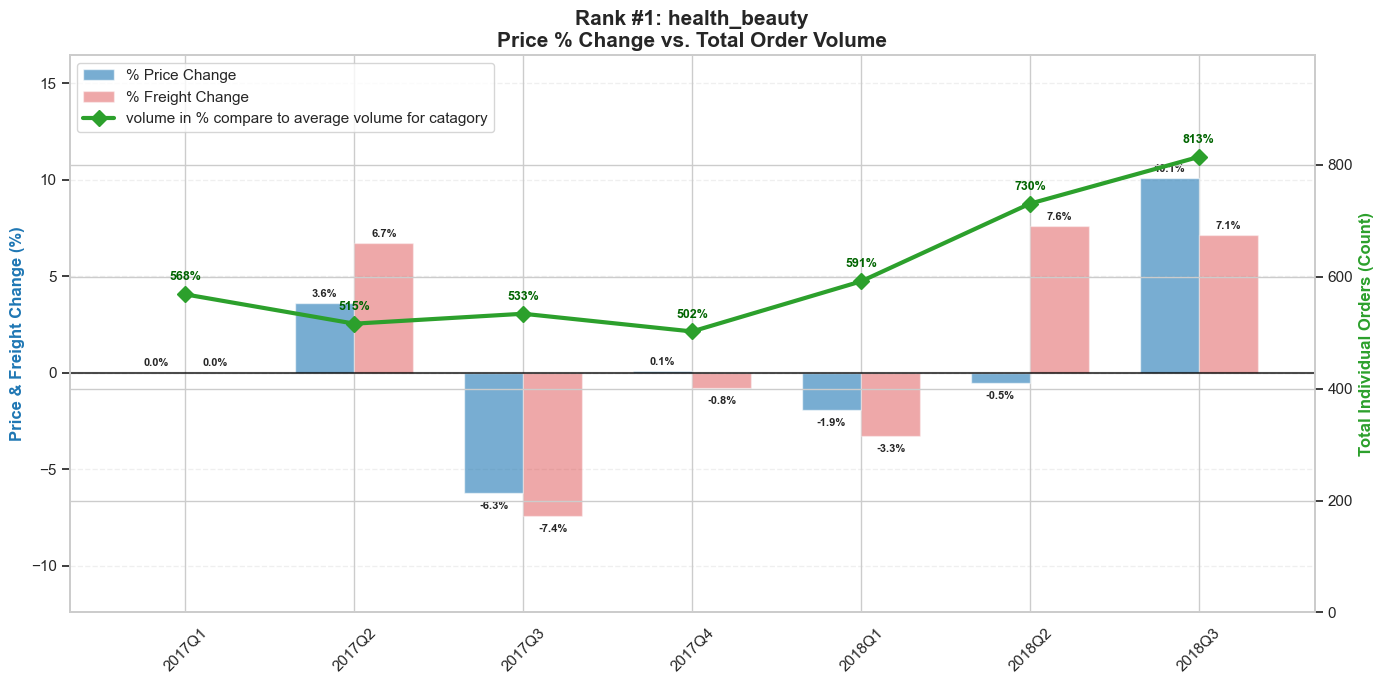

Category: health_beauty
Average Elasticity: 0.01
Recommended Price Action: 8.00%


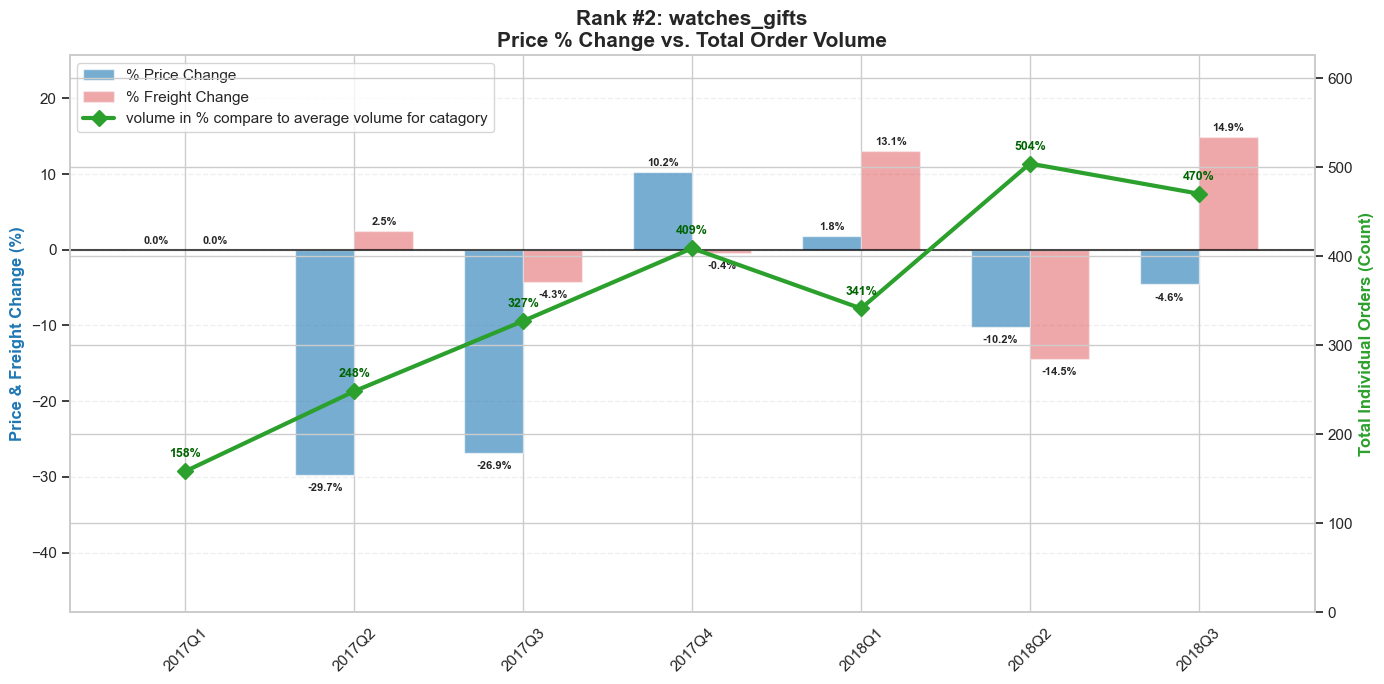

Category: watches_gifts
Average Elasticity: -0.09
Recommended Price Action: 18.59%


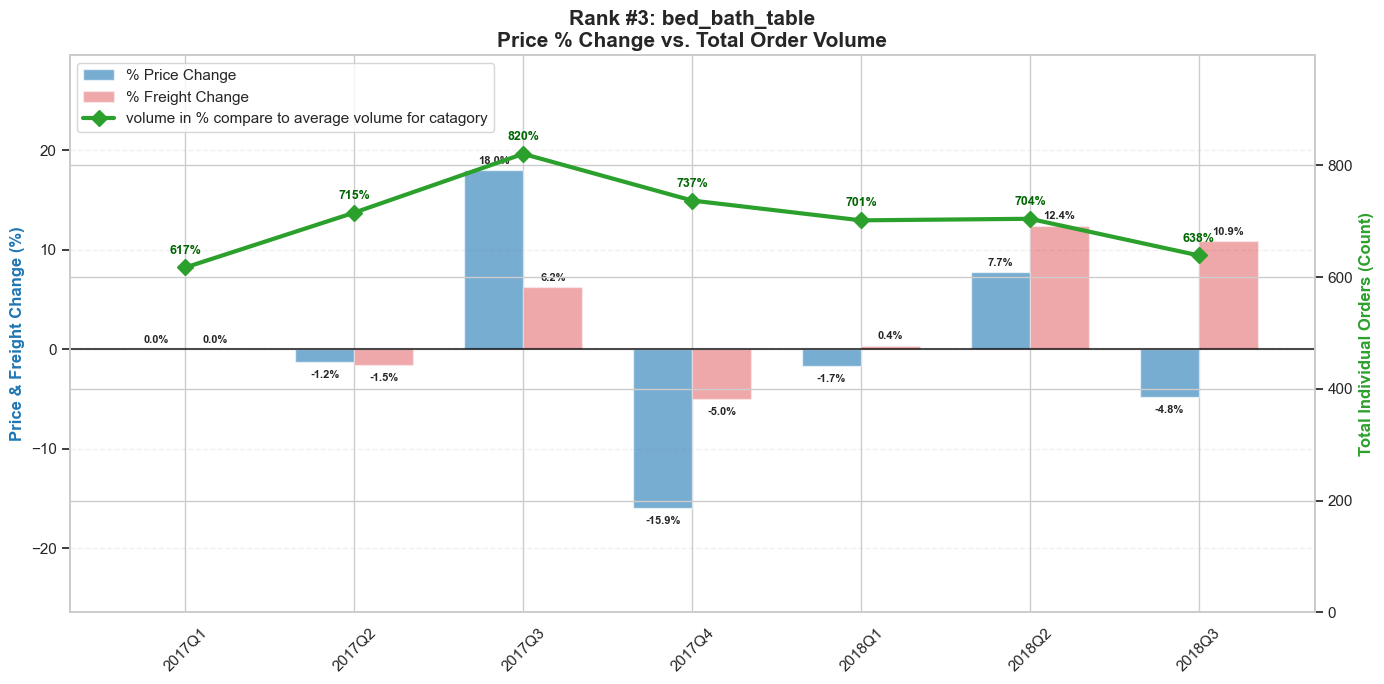

Category: bed_bath_table
Average Elasticity: -0.03
Recommended Price Action: 19.51%


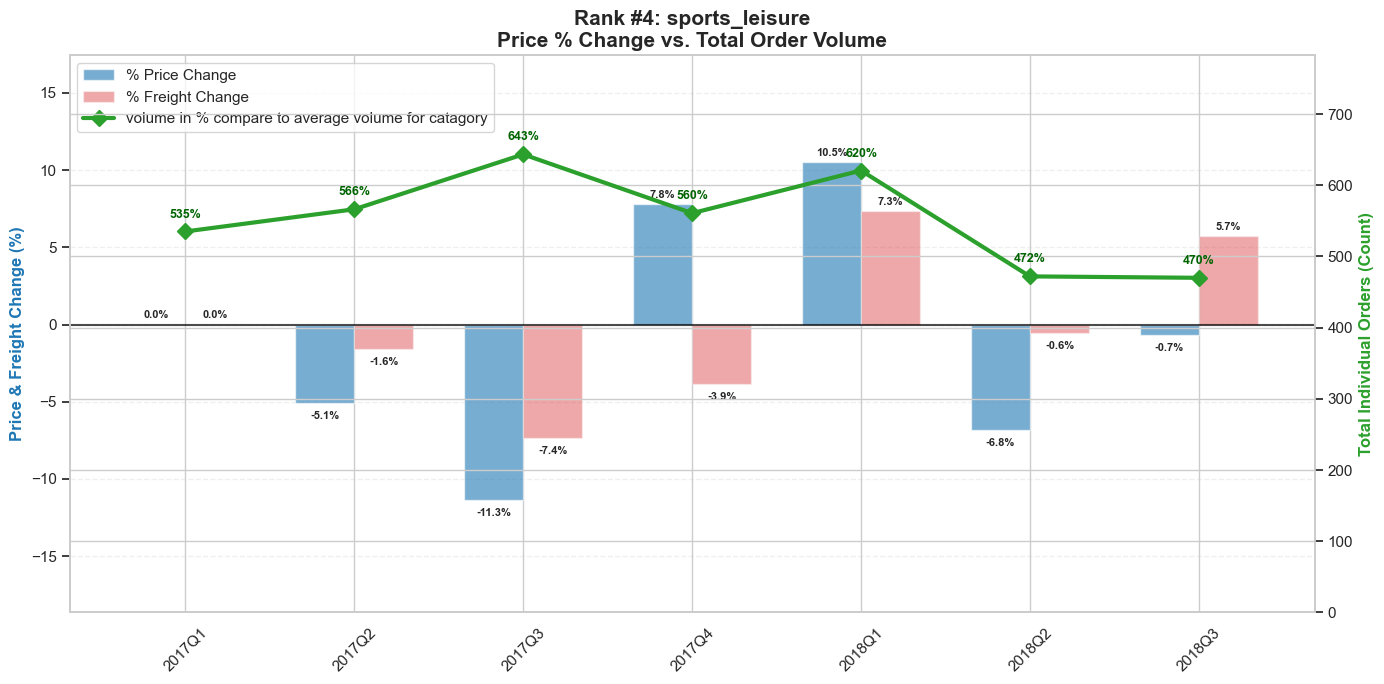

Category: sports_leisure
Average Elasticity: 0.07
Recommended Price Action: 8.00%


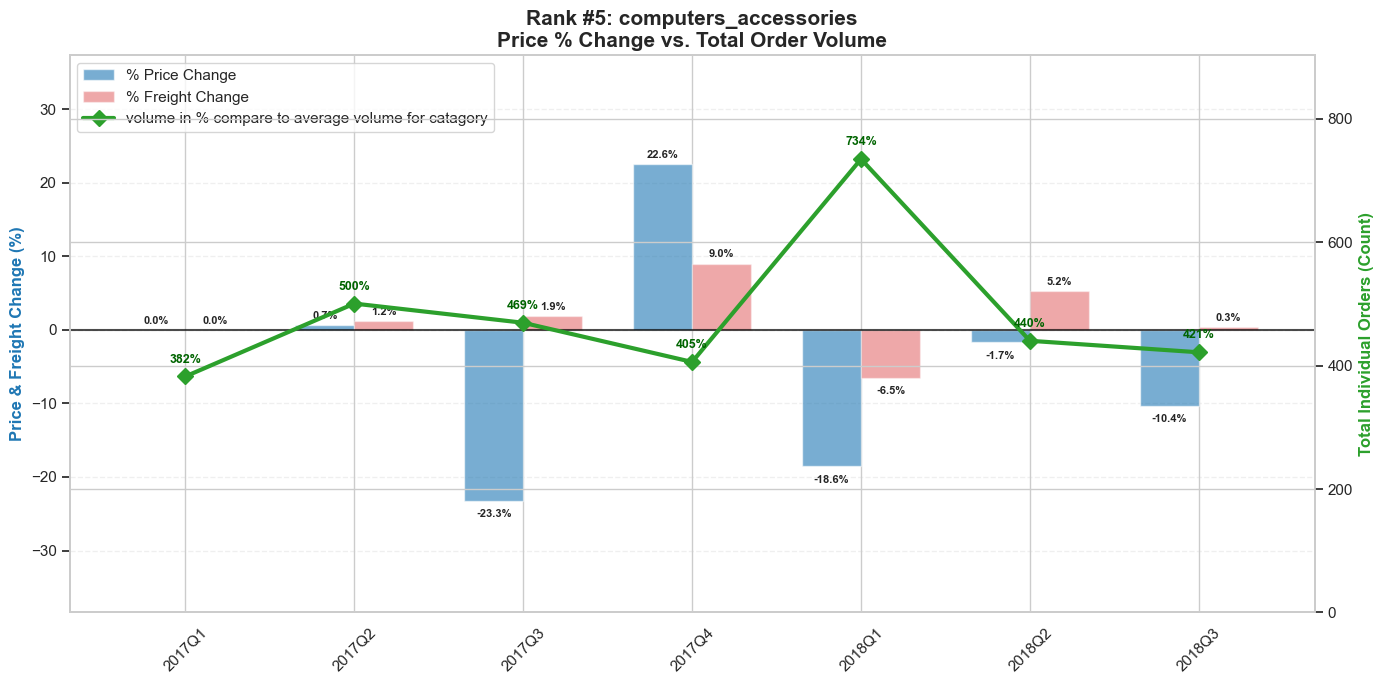

Category: computers_accessories
Average Elasticity: -0.02
Recommended Price Action: 19.67%


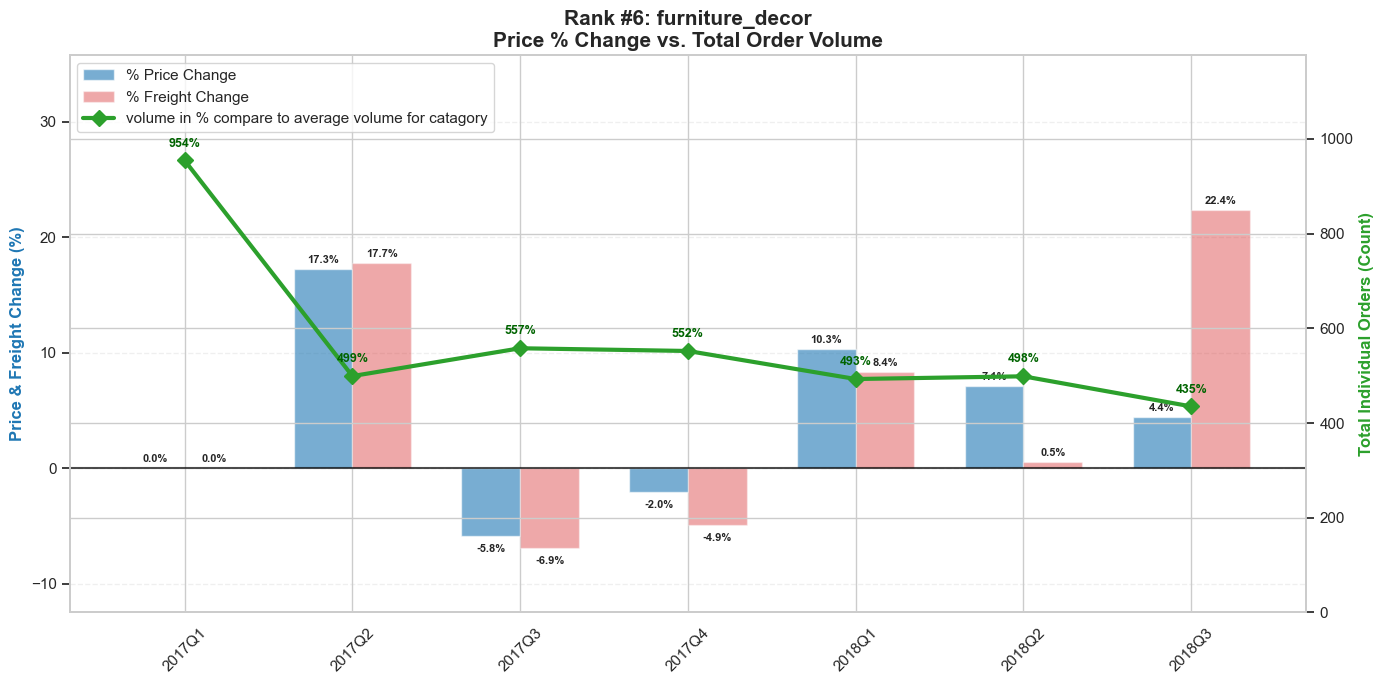

Category: furniture_decor
Average Elasticity: -0.01
Recommended Price Action: 19.90%


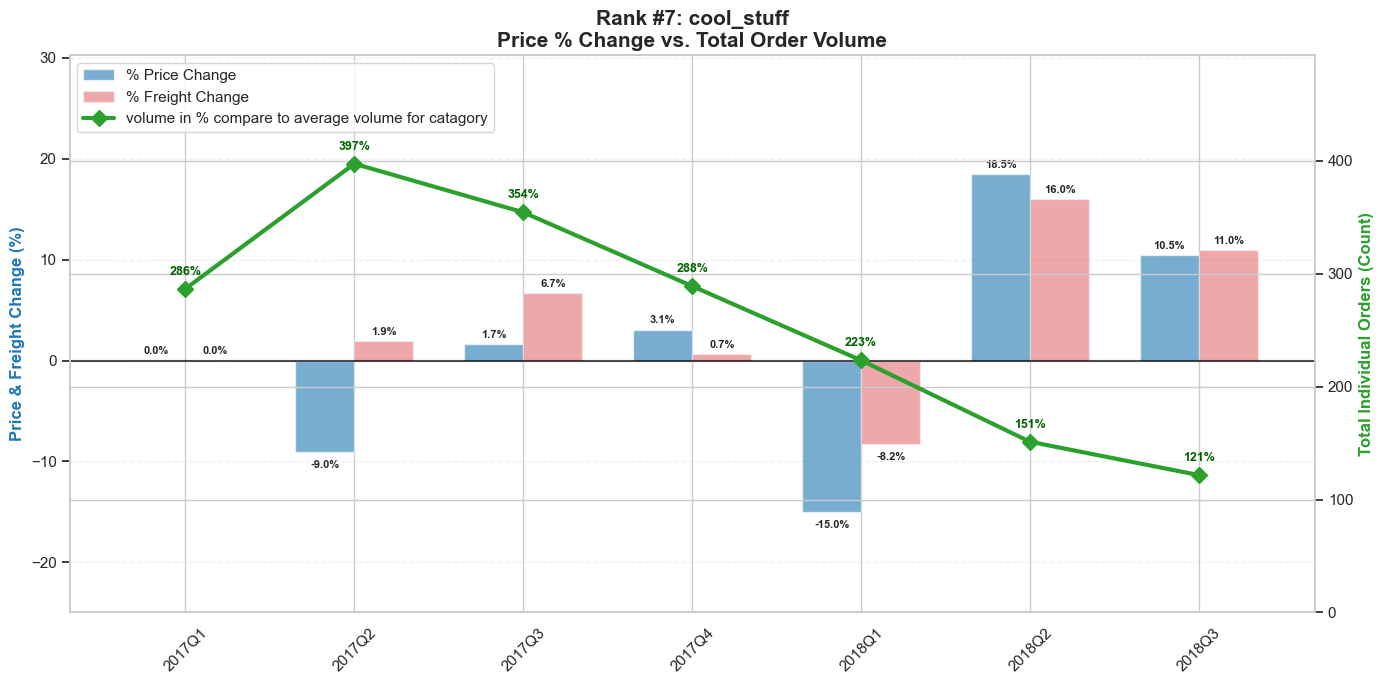

Category: cool_stuff
Average Elasticity: -0.02
Recommended Price Action: 19.75%


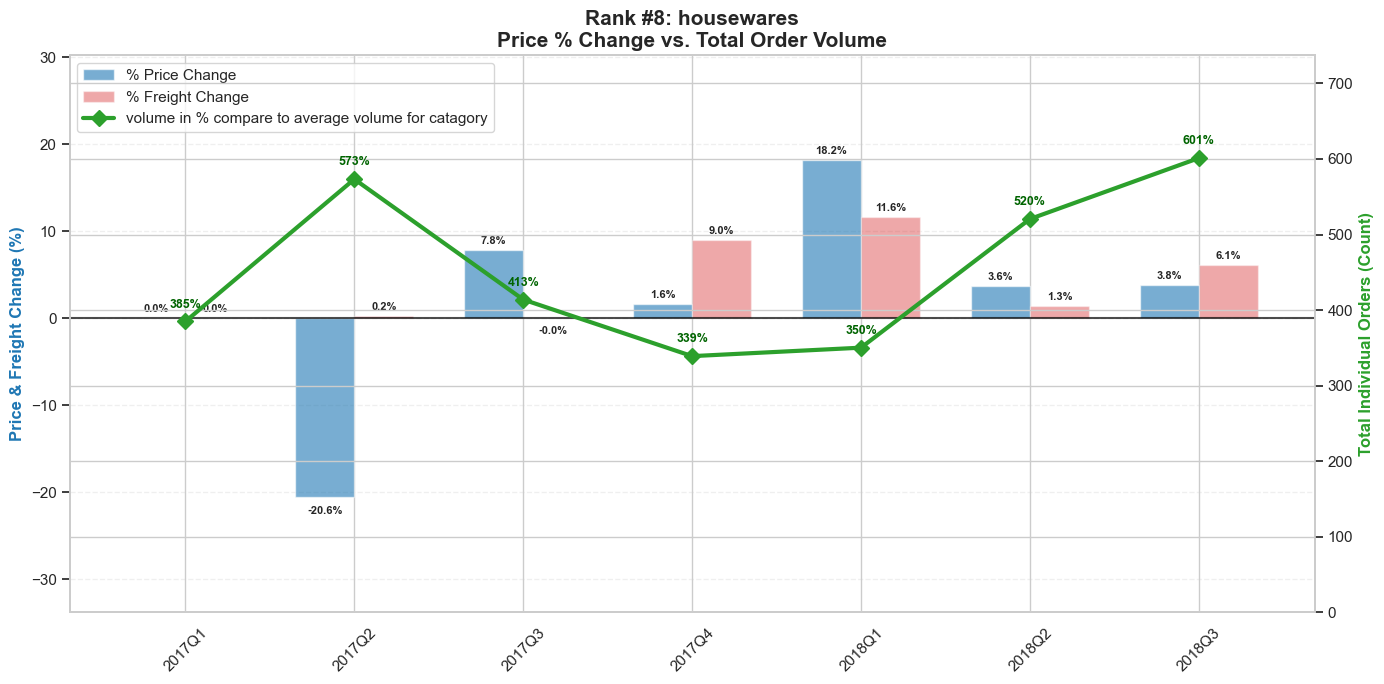

Category: housewares
Average Elasticity: 4.74
Recommended Price Action: 8.00%


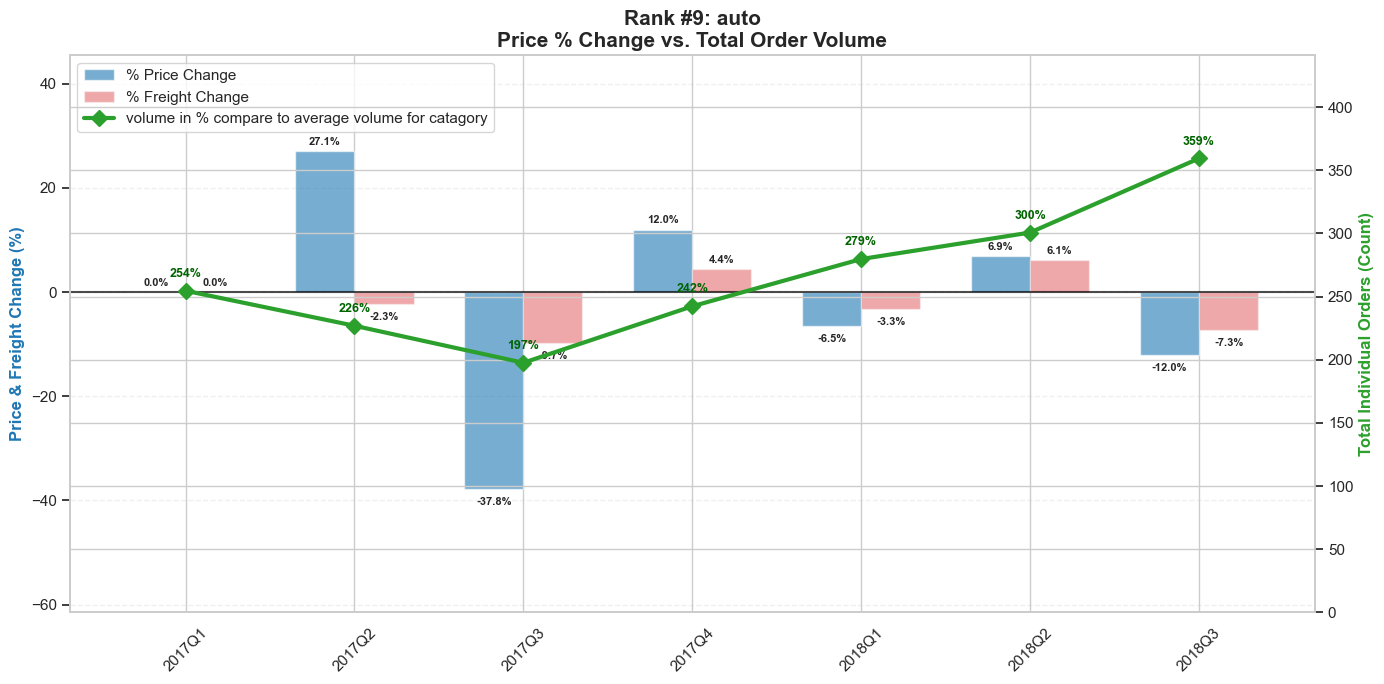

Category: auto
Average Elasticity: 0.01
Recommended Price Action: 8.00%


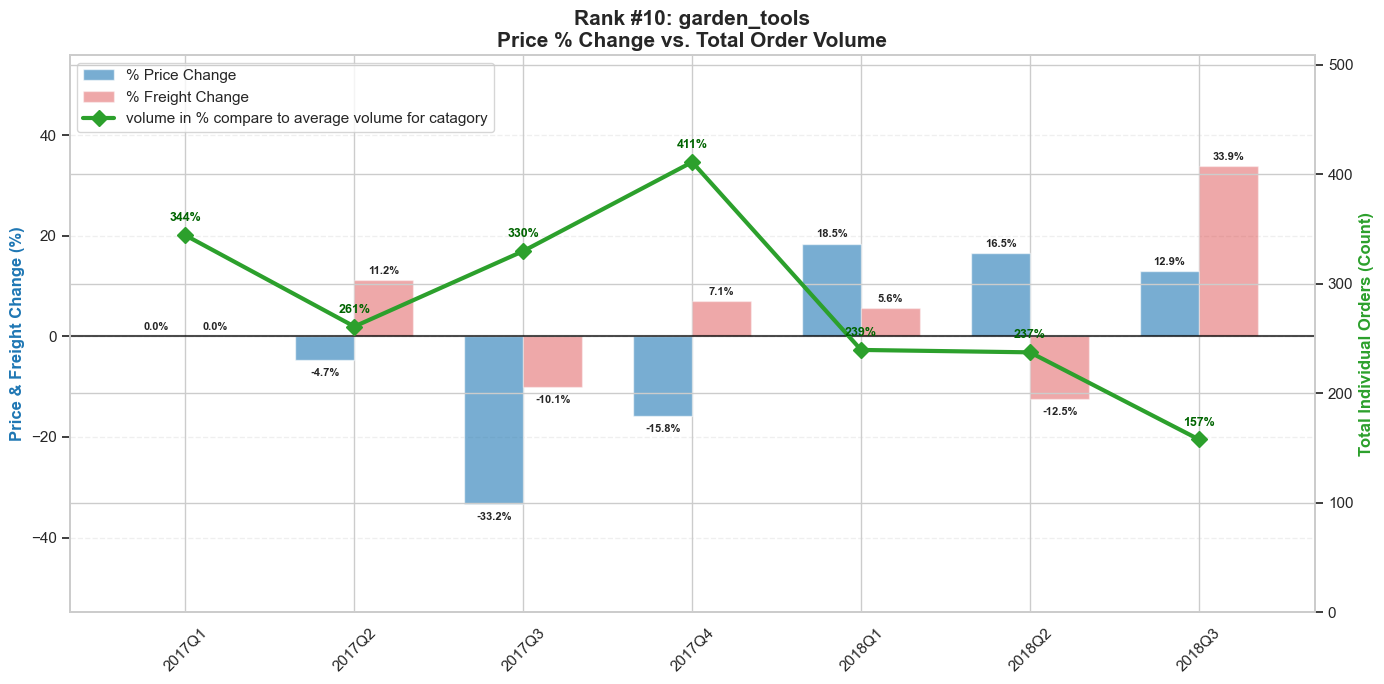

Category: garden_tools
Average Elasticity: -0.02
Recommended Price Action: 19.76%


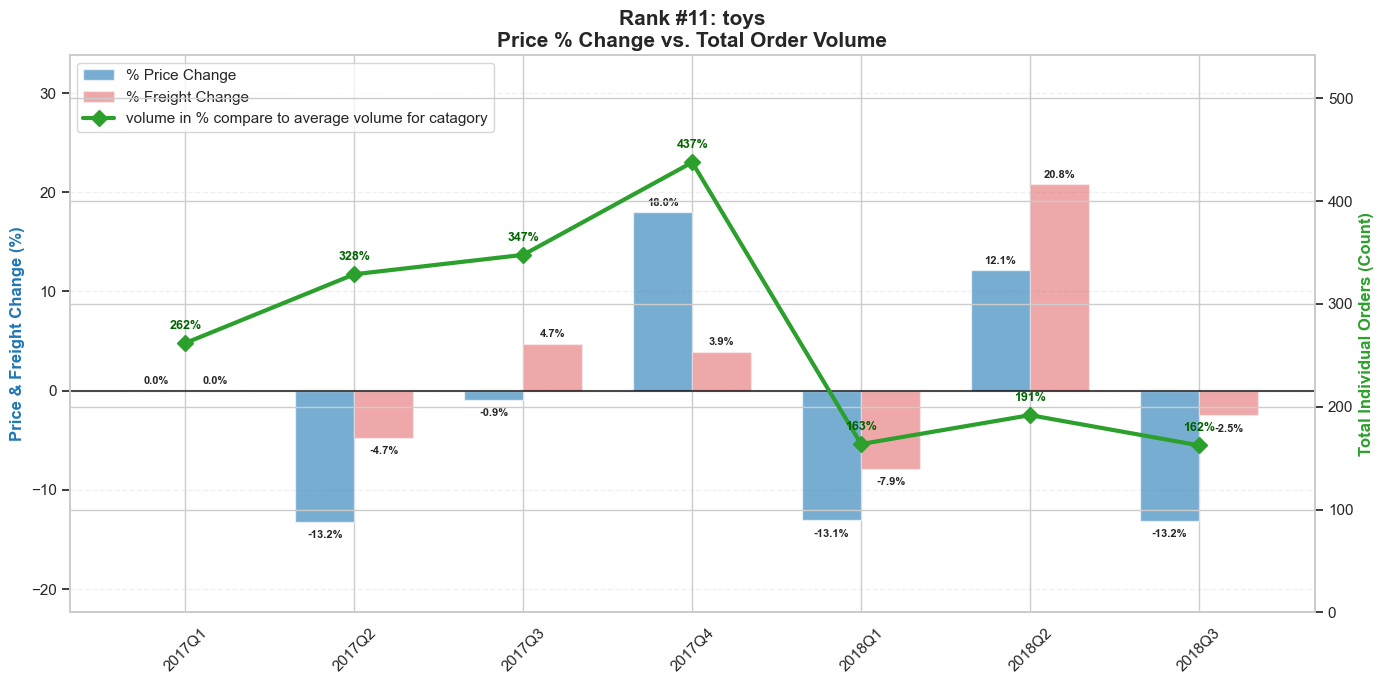

Category: toys
Average Elasticity: 0.03
Recommended Price Action: 8.00%


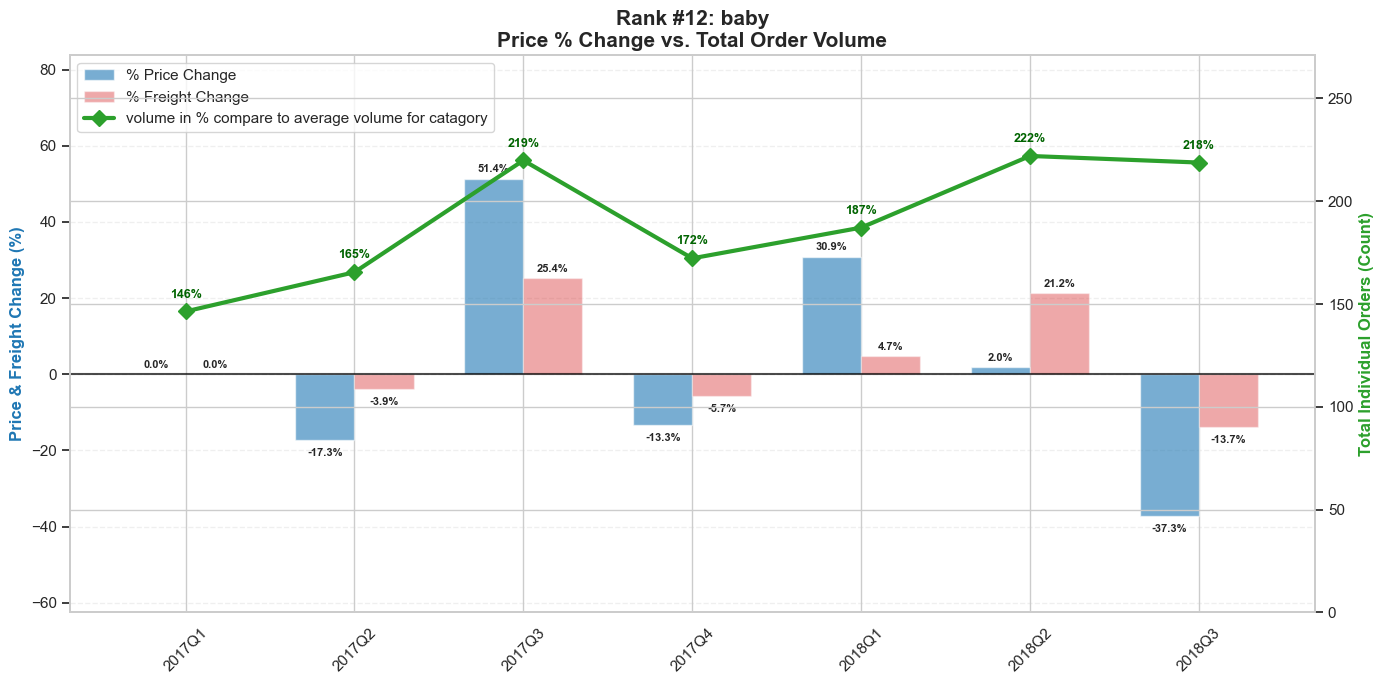

Category: baby
Average Elasticity: 0.01
Recommended Price Action: 8.00%


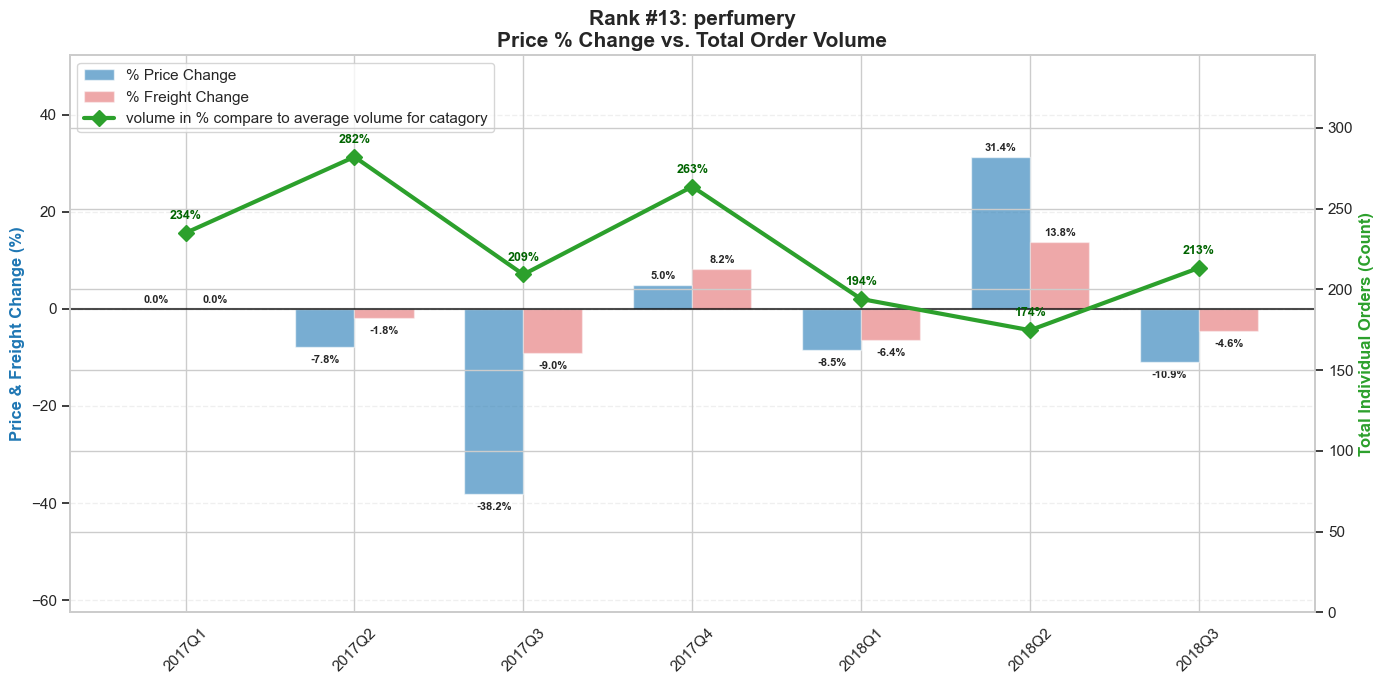

Category: perfumery
Average Elasticity: -0.01
Recommended Price Action: 19.83%


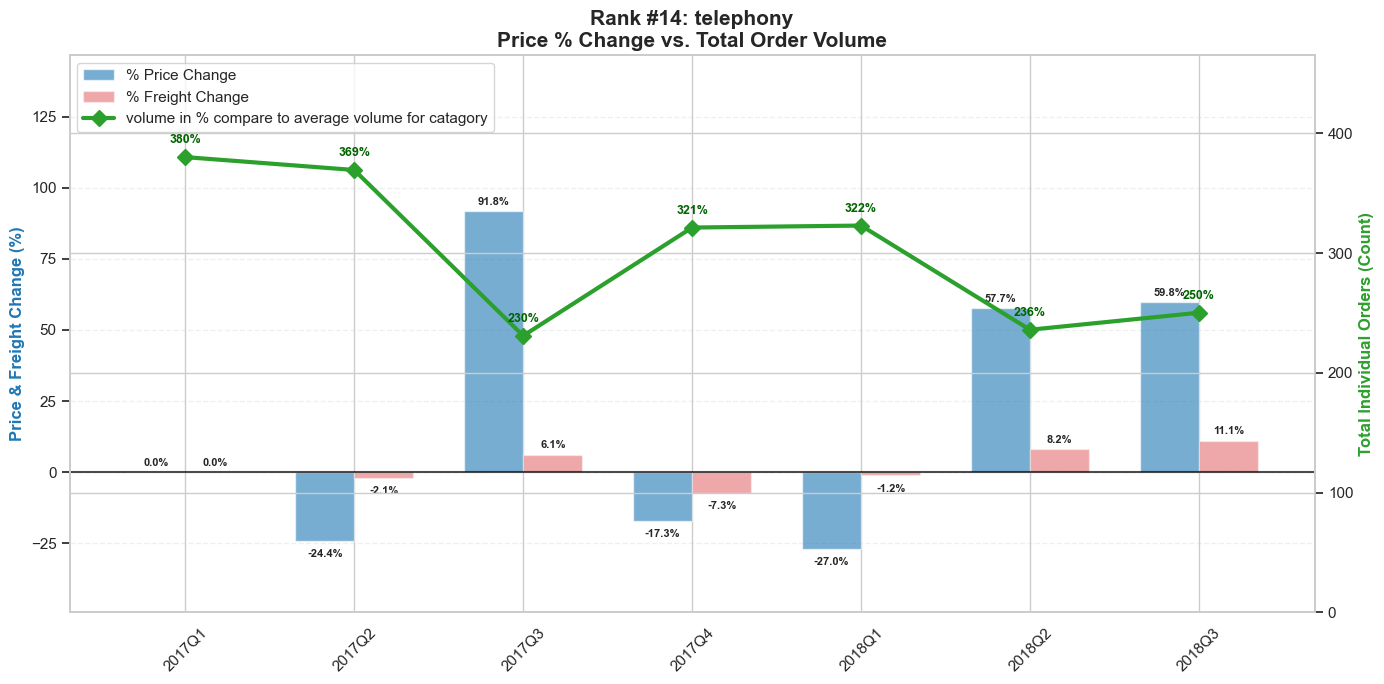

Category: telephony
Average Elasticity: -0.02
Recommended Price Action: 19.67%


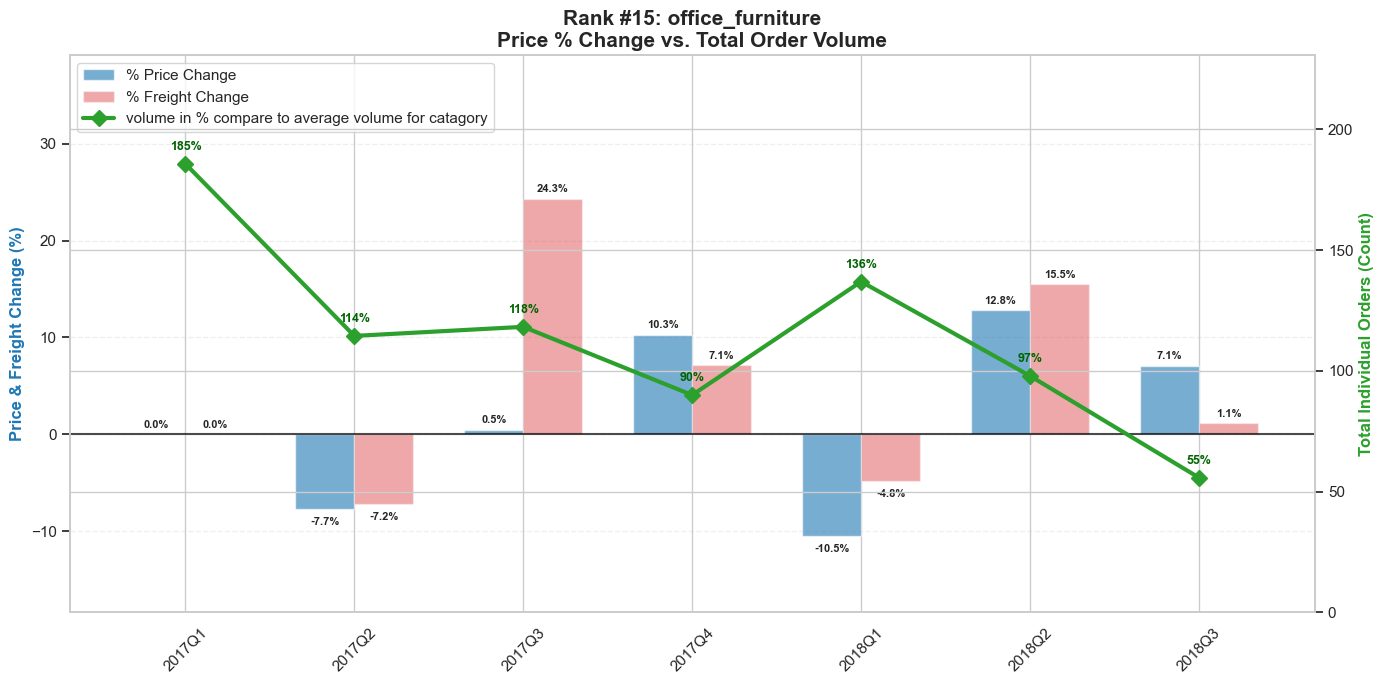

Category: office_furniture
Average Elasticity: -0.08
Recommended Price Action: 18.77%


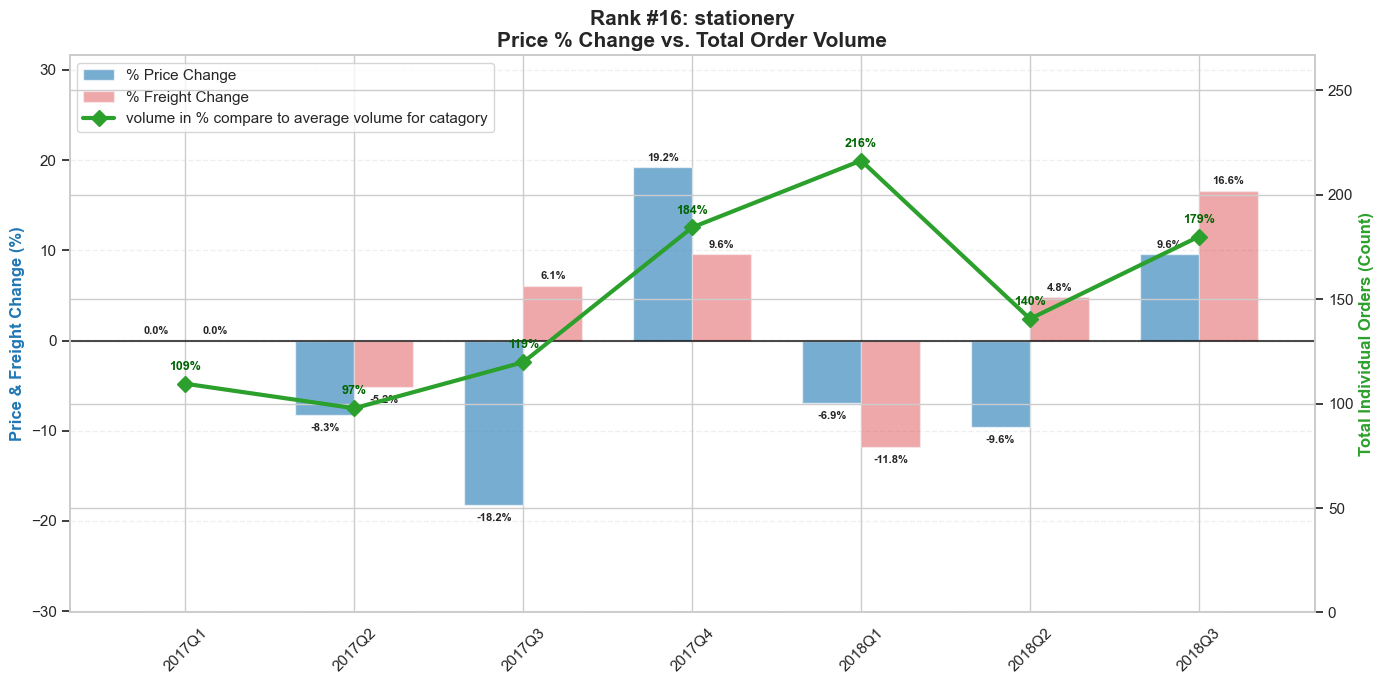

Category: stationery
Average Elasticity: 0.01
Recommended Price Action: 8.00%


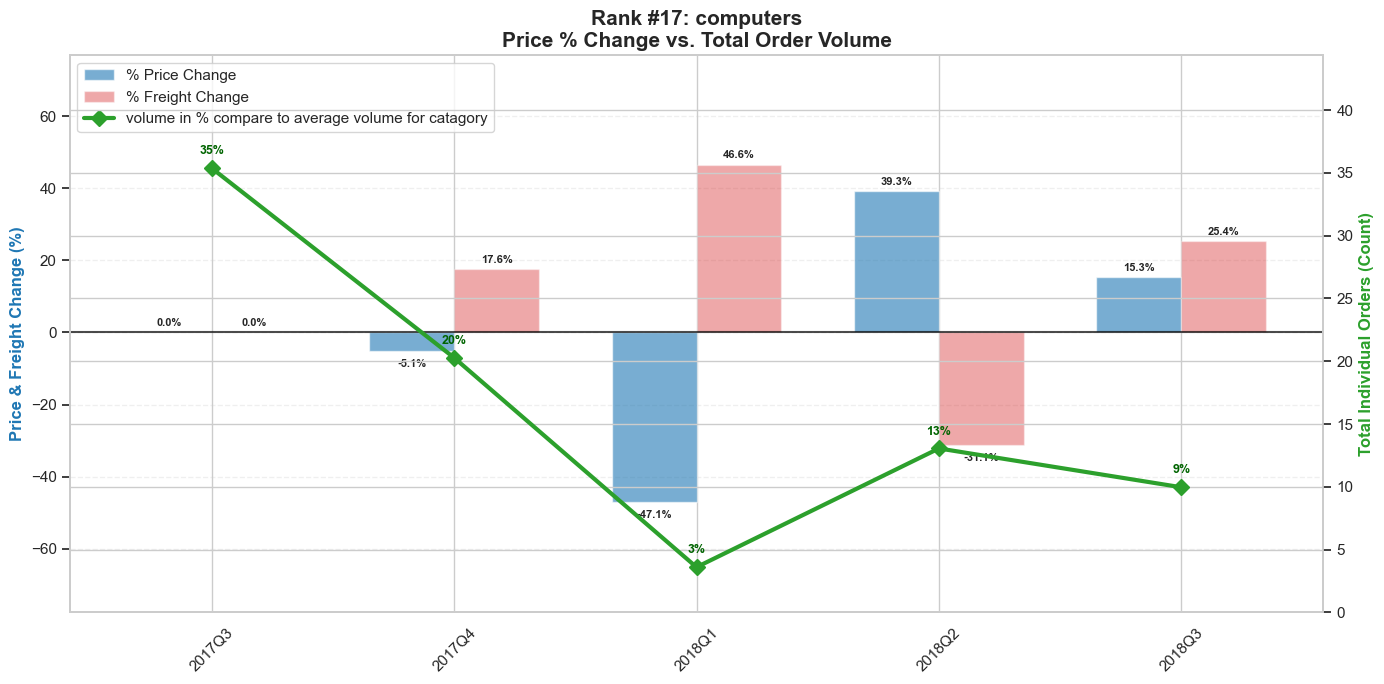

Category: computers
Average Elasticity: -0.03
Recommended Price Action: 19.49%


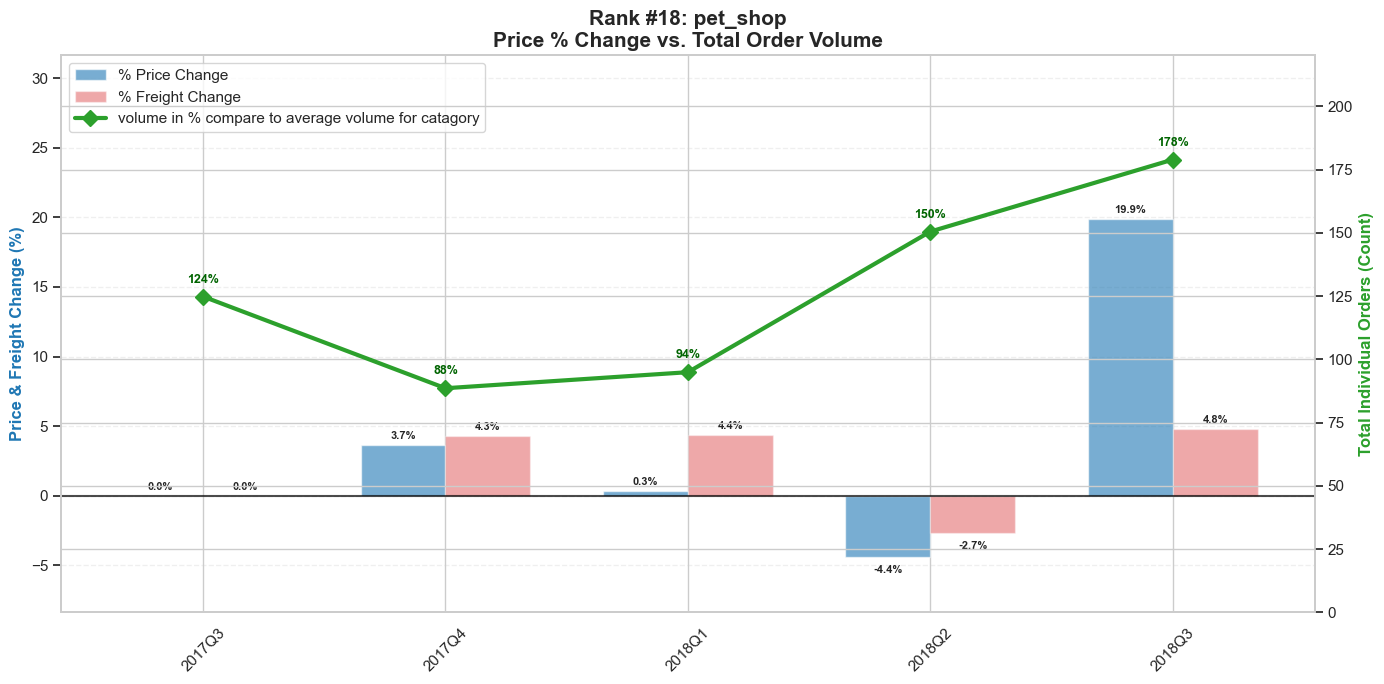

Category: pet_shop
Average Elasticity: -0.06
Recommended Price Action: 19.14%


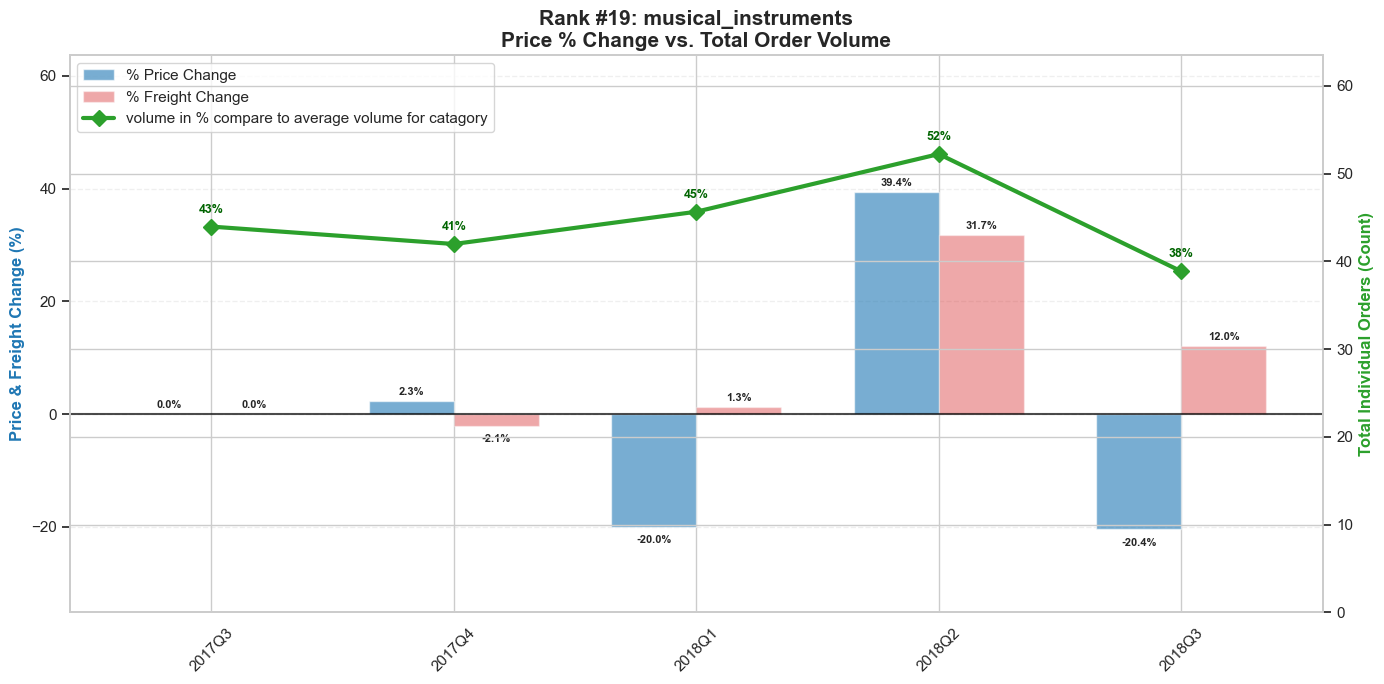

Category: musical_instruments
Average Elasticity: 0.02
Recommended Price Action: 8.00%


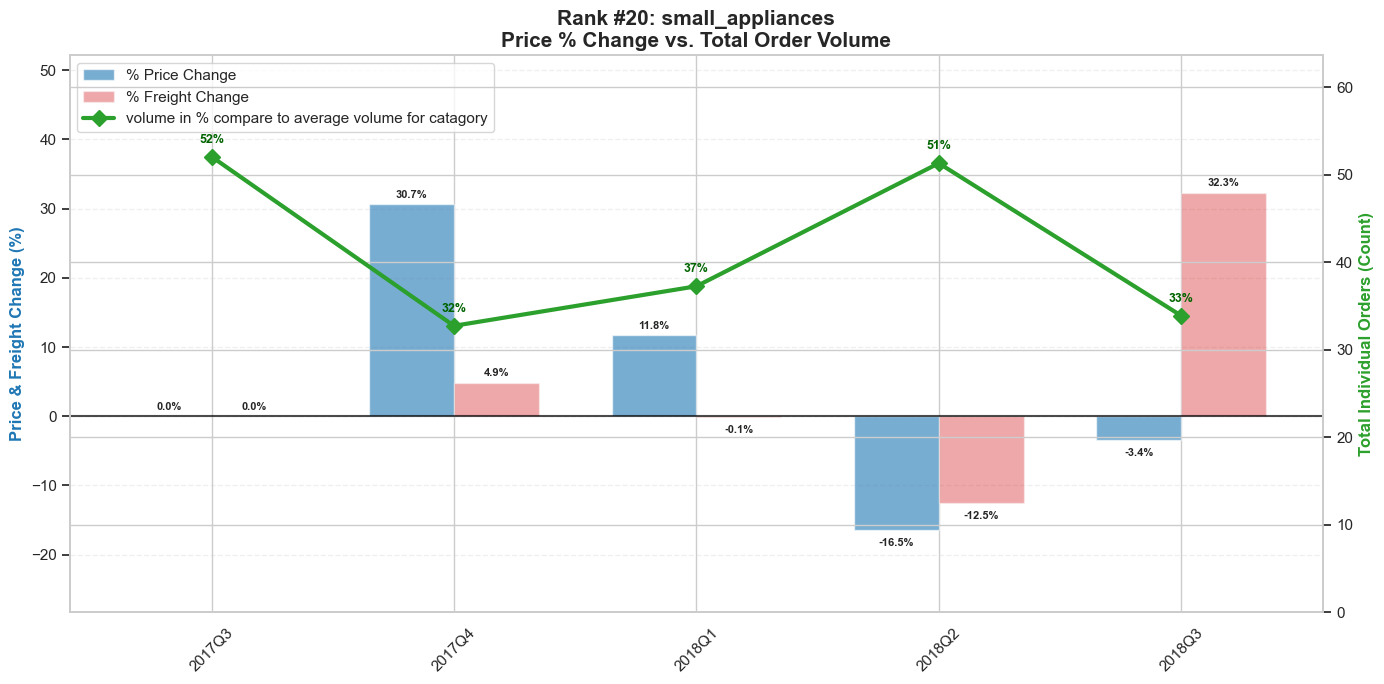

Category: small_appliances
Average Elasticity: -0.41
Recommended Price Action: 13.85%


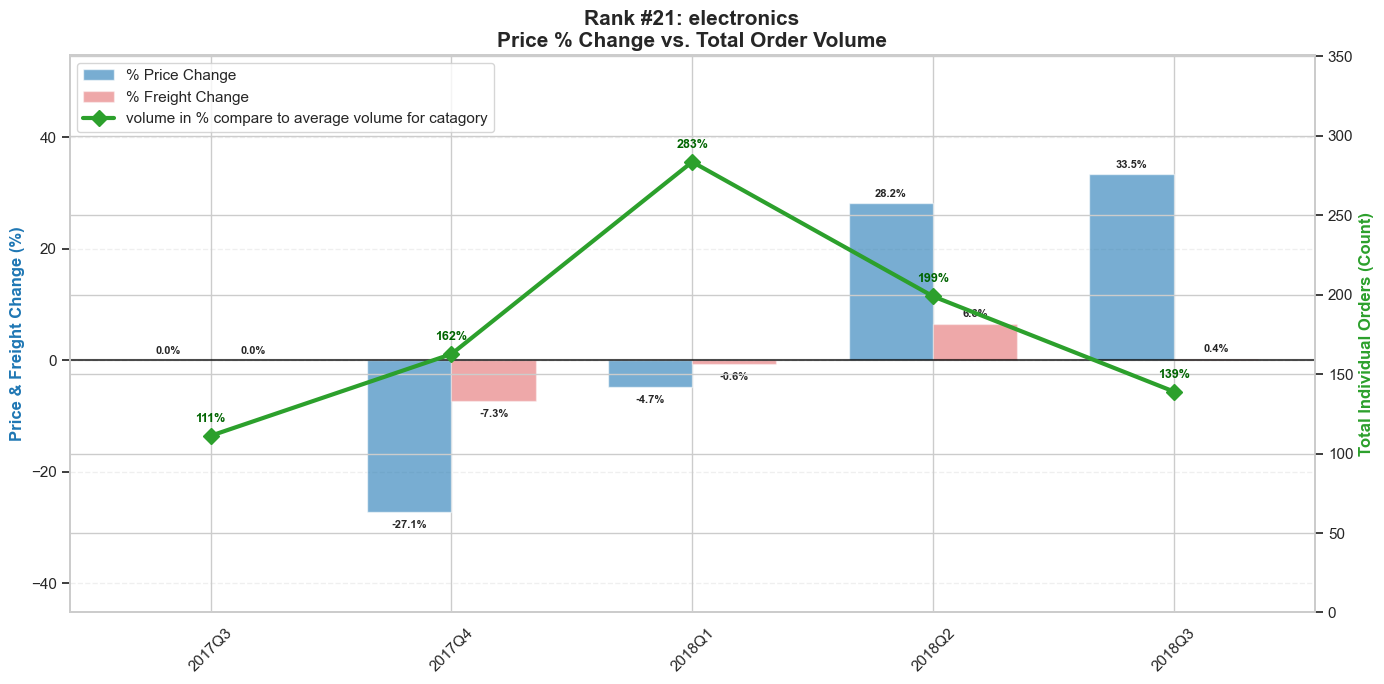

Category: electronics
Average Elasticity: -0.53
Recommended Price Action: 12.05%


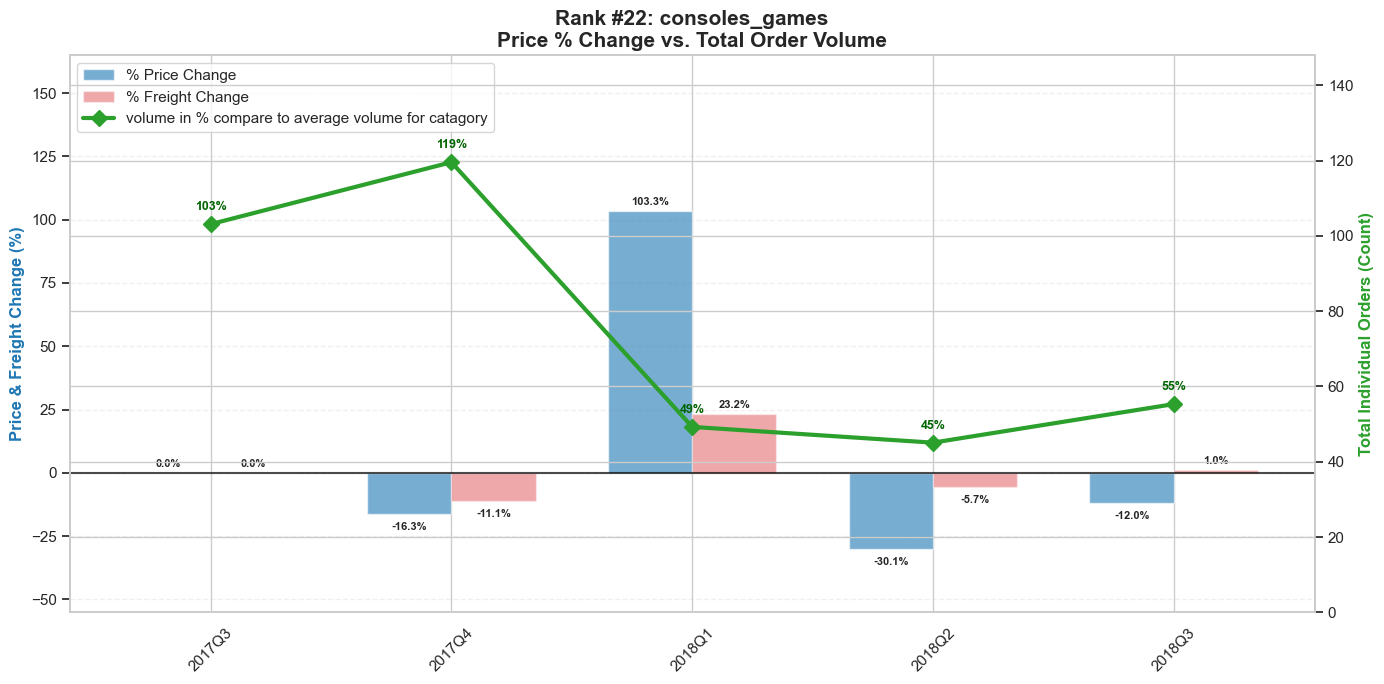

Category: consoles_games
Average Elasticity: 0.05
Recommended Price Action: 8.00%


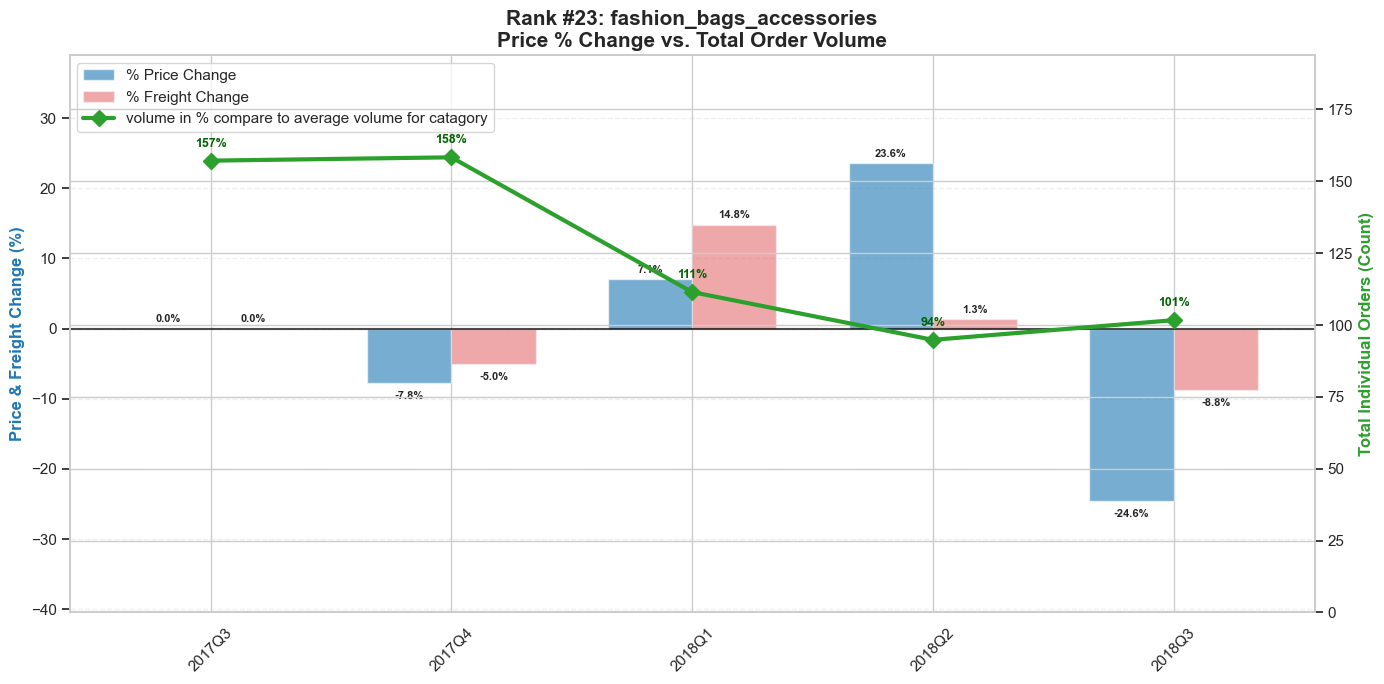

Category: fashion_bags_accessories
Average Elasticity: -0.04
Recommended Price Action: 19.46%


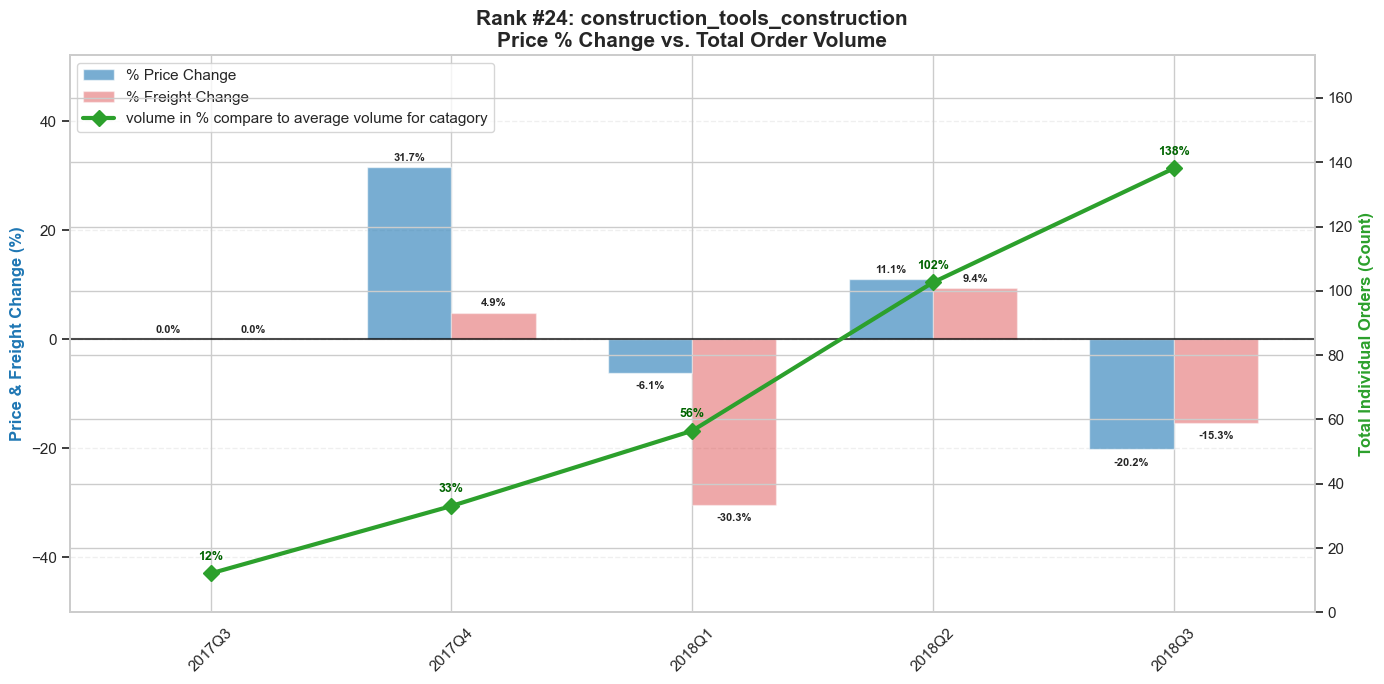

Category: construction_tools_construction
Average Elasticity: 0.10
Recommended Price Action: 8.00%


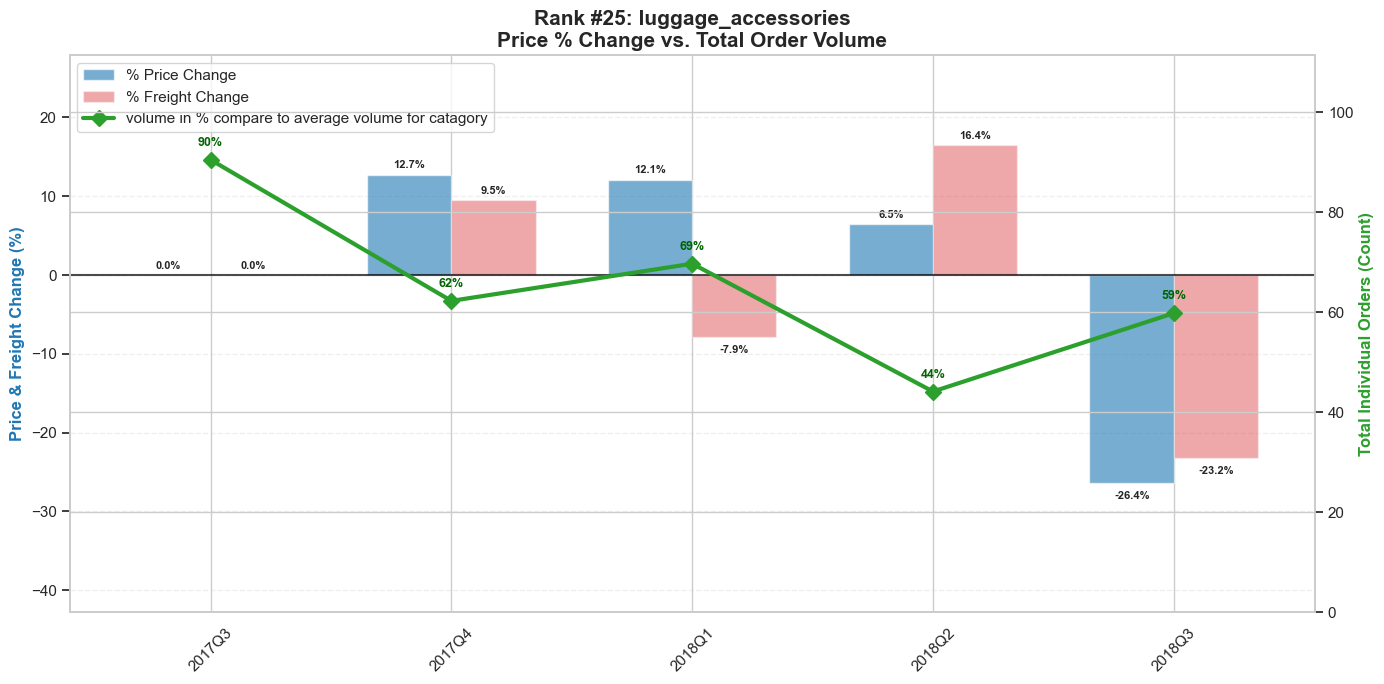

Category: luggage_accessories
Average Elasticity: -0.02
Recommended Price Action: 19.68%


In [279]:
quarters_to_drop = [pd.Period('2016Q3', freq='Q'), pd.Period('2016Q4', freq='Q')]

for i in range(25):
    # current category
    category = metrics.sum_price.sort_values(ascending=False).index[i]
    #give me the df for the current category
    cat_df = df[df['product_category_name_english'] == category].copy()
    total_category = df['product_category_name_english'].nunique()
    # sum of price and freight value in that catagory grouped by quarter order_id gets the value of the number of orders
    monthly_data = cat_df.groupby(cat_df['order_purchase_timestamp'].dt.to_period('Q')).agg({
        'price': 'sum',
        'freight_value': 'sum',
        'order_id': 'count' 
    })

    monthly_volume = df.groupby(df['order_purchase_timestamp'].dt.to_period('Q')).agg({
    'order_id': 'count' 
    })
    if i>15:
        quarters_to_drop = [pd.Period('2016Q3', freq='Q'), pd.Period('2016Q4', freq='Q'),pd.Period('2017Q1', freq='Q'),pd.Period('2017Q2', freq='Q')]

    monthly_volume=monthly_volume.drop(quarters_to_drop, errors='ignore')
    monthly_data = monthly_data.drop(quarters_to_drop, errors='ignore')

    
    # average price and freight value per order
    monthly_data['avg_price_per_order'] = monthly_data['price'] / monthly_data['order_id']
    monthly_data['avg_freight_per_order'] = monthly_data['freight_value'] / monthly_data['order_id']
    
    #remove first 2 values the orders peak extreemly at the beginning becose the first qurter bearly has orders. -> begining of the buiseness
    

    # precentage changes
    price_pct = monthly_data[['avg_price_per_order', 'avg_freight_per_order']].pct_change() * 100
    price_pct = price_pct.fillna(0)
    
    #volume for category for order devided by monthly volume average for catagory
    volume_absolute = monthly_data['order_id']*100/(monthly_volume['order_id']/total_category)
    

    # precenbtage change in price - only price seince that our revenue
    pct_change_price=monthly_data['avg_freight_per_order'].pct_change() * 100
    # precentage chnage in volume
    pct_change_volume=volume_absolute.pct_change()

    elasticity = (pct_change_volume.fillna(0) / pct_change_price.fillna(0)).mean()

    # dates
    labels = price_pct.index.astype(str)
    x = np.arange(len(labels))  
    width = 0.35  

    # 5. בניית הגרף
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # each piller is the two pillers for freight and price
    rects1 = ax1.bar(x - width/2, price_pct['avg_price_per_order'], width, 
                    label='% Price Change', color='tab:blue', alpha=0.6)
    rects2 = ax1.bar(x + width/2, price_pct['avg_freight_per_order'], width, 
                    label='% Freight Change', color='tab:red', alpha=0.4)

    # makes it so we have 2 y axis so we can see both values
    ax2 = ax1.twinx()
    ax2.plot(x, volume_absolute, color='tab:green', marker='D', 
             markersize=8, linewidth=3, label='volume in % compare to average volume for catagory')

    # 
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax1.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3 if height >= 0 else -13),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    # show order values
    for j, val in enumerate(volume_absolute):
        ax2.annotate(f'{int(val)}%', 
                     xy=(x[j], volume_absolute.iloc[j]),
                     xytext=(0, 10), 
                     textcoords="offset points",
                     ha='center', fontsize=9, color='darkgreen', fontweight='bold')

    # 
    ax1.set_ylabel('Price & Freight Change (%)', fontsize=12, fontweight='bold', color='tab:blue')
    ax2.set_ylabel('Total Individual Orders (Count)', fontsize=12, fontweight='bold', color='tab:green')
    
    plt.title(f'Rank #{i+1}: {category}\nPrice % Change vs. Total Order Volume', fontsize=15, fontweight='bold')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45)
    ax1.axhline(0, color='black', linewidth=1.5, alpha=0.7)
    
    # 
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    #
    y1_min, y1_max = ax1.get_ylim()
    ax1.set_ylim(y1_min * 1.5, y1_max * 1.5)
    
    y2_max = ax2.get_ylim()[1]
    ax2.set_ylim(0, y2_max * 1.2) 

    plt.tight_layout()
    plt.show()

    # optimal price calculation for category
    # 1. our profit margige for product right now: 12.5% estimated.
    current_margin = 0.125  


    if elasticity < -1:
        # optimal price change for elastic categories
        optimal_change_pct = ((elasticity / ((1 + elasticity) * (1 - current_margin))) - 1) * 100
    elif -1 <= elasticity <= 0:
        # optimal linear change 0 to -1 converted to 5%-20%
        optimal_change_pct = 5 + (elasticity - (-1)) * (20 - 5) / (0 - (-1))
    else:
        #for positive elasticity we will increase price with caution 
        # seince it contredict logic we will see how it behave with median increase in price set to 8%
        optimal_change_pct = 8.0

    print(f"Category: {category}")
    print(f"Average Elasticity: {elasticity:.2f}")
    print(f"Recommended Price Action: {optimal_change_pct:.2f}%")


after these analization we clearly see that price can be easly increased for much more profits as the elasticety is hard which mean we can increase price all whilst number of orders will remain simmilar in some categories it wasent affected, in housewere the elasticity were positive which can suggest that better products are more demanded 
but it is an anomaly that will need further testing


Business Strategy & Implementation Plan
High-Profit Core

Market Condition: Highly Inelastic Demand (PED > -0.4). Data indicates that customers in these categories are significantly insensitive to price changes.
Recommended Action: Implement an aggressive price increase of 15% to 20%.
Expected Impact: Immediate growth of 12%+ in Net Profit per category, while maintaining stable order volumes.

Stable Growth
Market Condition: Moderate Elasticity (PED between -0.4 and -0.6). There is a measurable but low sensitivity to price adjustments.
Recommended Action: Apply a moderate price increase of 5% to 15%.
Expected Impact: Sustained revenue growth with minimal churn, ensuring market share is preserved while optimizing margins.

Exploration Zone
Market Condition: Anomalous or Positive Elasticity (PED > 0). The data shows an unconventional relationship between price and demand, likely due to statistical noise or premium "Veblen" market niches.
Recommended Action: Execute a Controlled 10% Price Test.
Expected Impact: Collection of clean experimental data to identify high-value premium segments and refine the statistical model for future optimization.

watches_gifts have both low freight high price and high revenue impact which mean we should push this catagory up also it had low elasticity -0.1.
ourprofit margine on here will impact custumers the lowest while proffeting us the highest.


60% of revenue is in the months 3-8 50% higher then the rest of the year.

top 0.5% sellers (20) contribute 20% of the revenue! 
suggestions: we can slightly increase their fees as they highely proffitable on our platform and would not want to leave.
we should contact them indevitioall and understand what makes them stand out and preform so well.

41% of all costumers come from SP

delivery time does not corralete much for orders or revenu if we put allot of effort and money into faster and better deliveries it is a waiste that does not increase our costumers.

we have bad sellers (20) had 23% of all 1 start reviews which suggest the consistanly provide bad experience

location such as city and state did not had affect on experience 

right now the elasticity is not normelized by the the affect of qurter orders and price as they are neglible and would not affect havely on elasticety.
For this stage of the project, i chose not to normalize for seasonality to keep the models logic transparent. 
Future iterations could include seasonal weighting to further refine the elasticity coefficients.